# DSA8040 – Foundations of Data Analytics and AI – Assignment 2

### Student Name: Aamna Arif

---

## Section 1: Initial Exploratory Data Analysis (EDA)

This section describes the Wine dataset and explores the distribution shift in Shifted Test Set A. EDA is used in this report not just as a preliminary step, but for guiding modelling decisions, interpreting outcomes, and diagnosing model failures.

### Dataset Overview and Loading

The (UCI) Wine dataset consists of 13 continuous chemical measurements obtained from wine samples of three grape varieties (cultivars). The goal is to classify the wine by cultivar based on the chemical measurements.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv")
X_test_clean = pd.read_csv("X_test_clean.csv")
y_test = pd.read_csv("y_test.csv")
X_test_shifted = pd.read_csv("X_test_shifted_A.csv")

train_df = X_train.copy()
train_df['target'] = y_train
clean_df = X_test_clean.copy()
clean_df['target'] = y_test
shifted_df = X_test_shifted.copy()
shifted_df['target'] = y_test

print("Train shape:", train_df.shape)
print("Clean test shape:", clean_df.shape)
print("Shifted test shape:", shifted_df.shape)

train_df.head()

Train shape: (142, 14)
Clean test shape: (36, 14)
Shifted test shape: (36, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,13.28,1.64,2.84,15.5,110.0,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880.0,0
1,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0,0
2,13.39,1.77,2.62,16.1,93.0,2.85,2.94,0.34,1.45,4.80,0.92,3.22,1195.0,0
3,13.75,1.73,2.41,16.0,89.0,2.60,2.76,0.29,1.81,5.60,1.15,2.90,1320.0,0
4,13.32,3.24,2.38,21.5,92.0,1.93,0.76,0.45,1.25,8.42,0.55,1.62,650.0,2


### Data Quality Check — Missing Values

We first check the data is complete. Incomplete data can mask or be mistaken for a distribution shift, so we rule it out first.

In [10]:
missing_df = pd.DataFrame({
    'Train': X_train.isnull().sum(),
    'Clean Test': X_test_clean.isnull().sum(),
    'Shifted Test': X_test_shifted.isnull().sum()
})

missing_df.T

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
Train,0,0,0,0,0,0,0,0,0,0,0,0,0
Clean Test,0,0,0,0,0,0,0,0,0,0,0,0,0
Shifted Test,0,0,0,0,0,0,0,0,0,0,0,0,0


### Class Distribution

We check the class balance before modelling. Class imbalance can increase accuracy and skew models towards the majority class, so we expect this when we look at class-wise metrics.

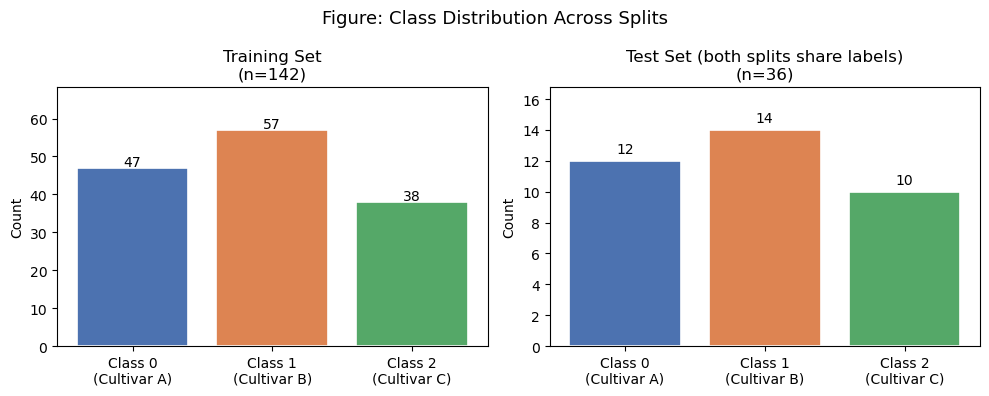

Class proportions (train): {0: 0.331, 1: 0.401, 2: 0.268}


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
class_names = ['Class 0\n(Cultivar A)', 'Class 1\n(Cultivar B)', 'Class 2\n(Cultivar C)']
colors = ['#4C72B0', '#DD8452', '#55A868']

train_counts = y_train.value_counts().sort_index()
test_counts  = y_test.value_counts().sort_index()

for ax, counts, title, n in [
    (axes[0], train_counts, 'Training Set', 142),
    (axes[1], test_counts,  'Test Set (both splits share labels)', 36)
]:
    ax.bar(class_names, counts.values, color=colors, edgecolor='white', linewidth=1.2)
    ax.set_title(f'{title}\n(n={n})', fontsize=12, fontweight='medium')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.2)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(v), ha='center', fontweight='medium')

plt.suptitle('Figure: Class Distribution Across Splits', fontsize=13, fontweight='medium')
plt.tight_layout()
plt.show()
train_counts = y_train.squeeze().value_counts().sort_index()

print( "Class proportions (train):", (train_counts / train_counts.sum()).round(3).to_dict())

**Observation:** The class distribution is fairly stable between the train and test splits. Class 2 is the minority in both (38 train; 10 test). This class is likely to be most affected by a distribution shift, as there are fewer observations from which to learn a good decision rule.

### Summary Statistics

We examine measures of central tendency, spread, and range for each feature across splits. This gives a first clue to which features are different between the clean and shifted test sets.

**Note:** We exclude the target column to prevent confusion of the class label (0, 1, 2) with a continuous numeric.

In [12]:
train_stats  = X_train.describe()
clean_stats  = X_test_clean.describe()
shifted_stats = X_test_shifted.describe()

combined_stats = pd.concat(
    [train_stats, clean_stats, shifted_stats], axis=1, keys=['Train', 'Clean Test', 'Shifted Test']
).round(3)

def mark_group_starts(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for col in df.columns:
        if col[0] in ['Clean Test', 'Shifted Test']:
            if col[1] == df[col[0]].columns[0]:
                styles[col] = 'border-left: 3px solid black'
    return styles

styled = (
    combined_stats.style
    .apply(mark_group_starts, axis=None)
    .set_table_styles([
        {'selector': 'th.col_heading.level0', 'props': [('text-align', 'center')]},
        {'selector': 'th.col_heading.level1', 'props': [('text-align', 'center')]},
        {'selector': 'th', 'props': [('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])
)
styled

### Identifying and Quantifying the Distribution Shift

A distribution shift is when the statistical distribution of the inputs changes. In this case, we have a **covariate shift**: the class labels have not changed, but the joint distribution of the inputs `P(X)` has changed. This should be compared with concept drift (where the function mapping inputs to labels changes).

To measure the shift, we calculate the difference in means (per feature) between the clean and shifted test sets, then divide by the training set standard deviation to get the shift in standard deviation units (how many standard deviations the mean has shifted by).

In [13]:
features = X_train.columns.tolist()

shift_summary = pd.DataFrame(index=features)
shift_summary['train_mean']    = X_train.mean()
shift_summary['train_std']     = X_train.std()
shift_summary['clean_mean']    = X_test_clean.mean()
shift_summary['shifted_mean']  = X_test_shifted.mean()
shift_summary['raw_offset']    = shift_summary['shifted_mean'] - shift_summary['clean_mean']
shift_summary['shift_in_stds'] = shift_summary['raw_offset'] / shift_summary['train_std']
shift_summary['is_shifted']    = shift_summary['shift_in_stds'].abs() > 0.5
shift_summary.round(3)

,train_mean,train_std,clean_mean,shifted_mean,raw_offset,shift_in_stds,is_shifted
alcohol,12.971,0.803,13.116,13.116,0.000,0.000,False
malic_acid,2.340,1.101,2.322,2.322,0.000,0.000,False
ash,2.365,0.268,2.373,2.774,0.401,1.495,True
alcalinity_of_ash,19.625,3.381,18.981,24.034,5.053,1.495,True
magnesium,99.634,14.937,100.167,100.167,0.000,0.000,False
total_phenols,2.274,0.621,2.379,2.379,0.000,0.000,False
flavanoids,1.985,0.952,2.203,0.780,-1.423,-1.495,True
nonflavanoid_phenols,0.360,0.119,0.369,0.369,0.000,0.000,False
proanthocyanins,1.600,0.580,1.554,2.421,0.867,1.495,True
color_intensity,4.990,2.335,5.328,5.328,0.000,0.000,False


**Key findings:** Five features are affected, each shifted by a **constant additive offset** — confirmed by the fact that standard deviations are identical between clean and shifted sets:

| Feature | Raw Offset | Shift (std units) | Direction |
|---|---|---|---|
| `ash` | +0.40 | +1.50 σ | increase |
| `alcalinity_of_ash` | +5.05 | +1.50 σ | increase |
| `flavanoids` | −1.42 | **−1.50 σ** | decrease |
| `proanthocyanins` | +0.87 | +1.50 σ | increase |
| `proline` | **−450.65** | **−1.50 σ** | decrease |

The five affected features are all shifted by ±1.50σ - a systematic shift, indicative of a **sensor calibration problem** or measurement artefact rather than noise. The `proline` shift leads to **physically impossible negative values** (minimum: −160.6). The other 8 features are not affected.

### Feature Distribution Plots

#### All Features — KDE Overview

First, we present KDEs of all 13 features. The 8 features are untouched, the shifted 5 are visible.

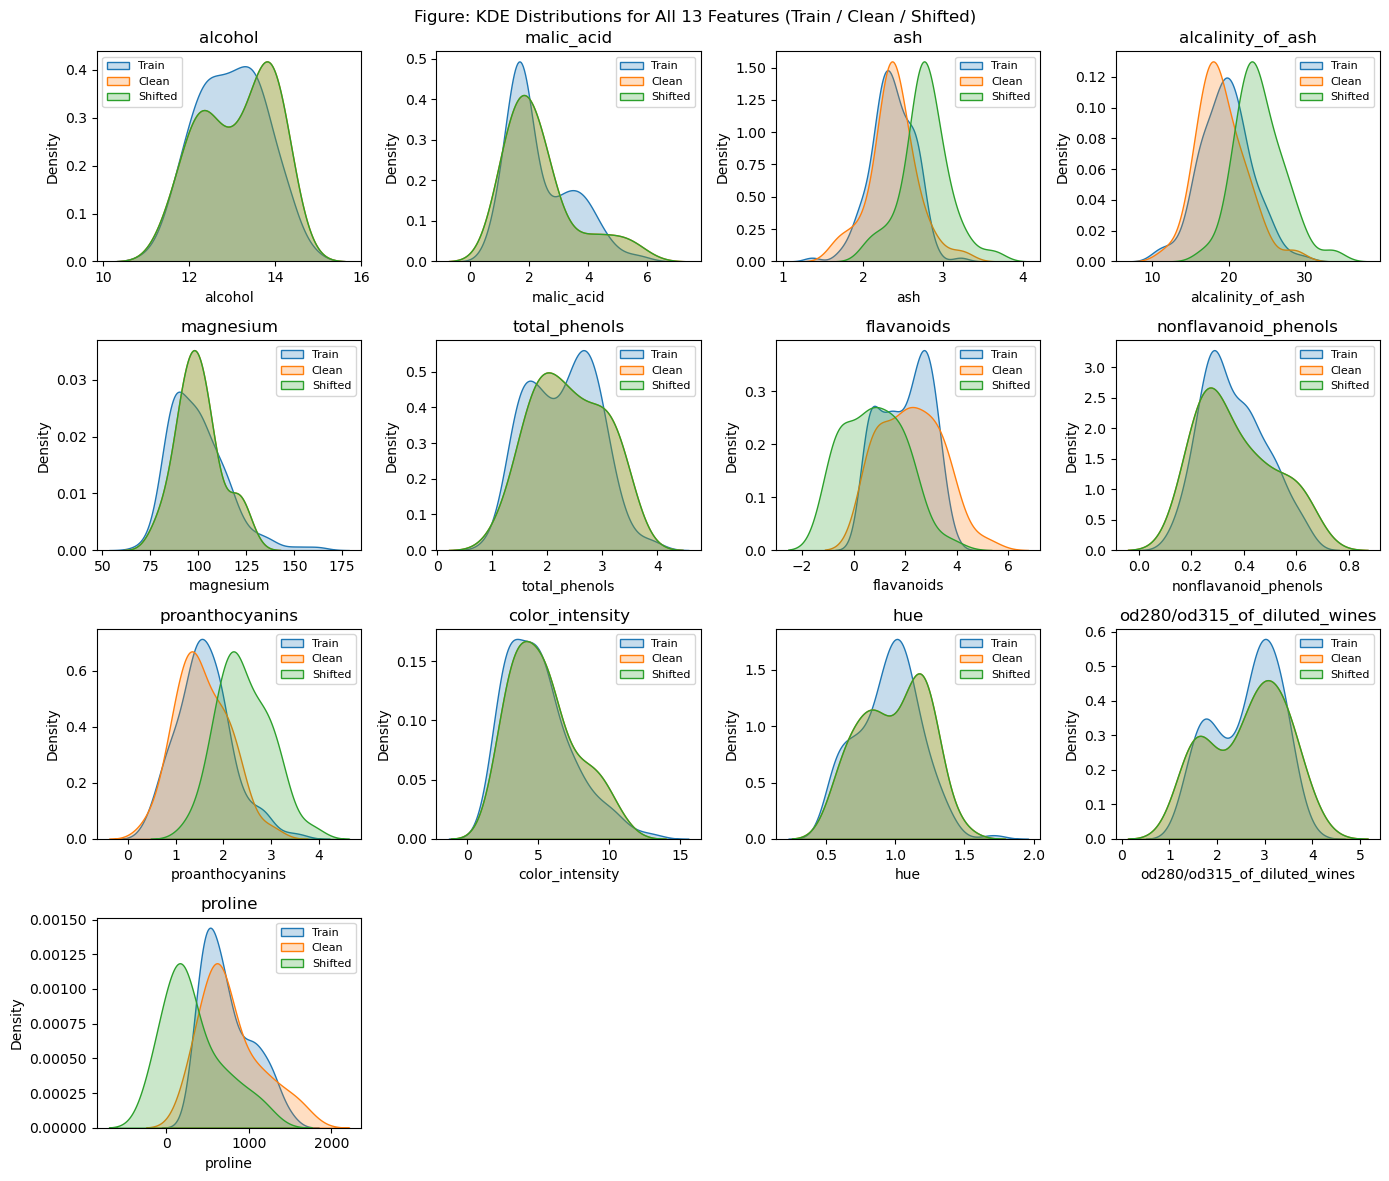

In [14]:
features = X_train.columns

fig, axes = plt.subplots(4, 4, figsize=(14, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.kdeplot(train_df[feature], label="Train", ax=axes[i], fill=True)
    sns.kdeplot(clean_df[feature], label="Clean", ax=axes[i], fill=True)
    sns.kdeplot(shifted_df[feature], label="Shifted", ax=axes[i], fill=True)
    axes[i].set_title(feature)
    axes[i].legend(fontsize=8)

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Figure: KDE Distributions for All 13 Features (Train / Clean / Shifted)', fontsize=12, fontweight='medium')
plt.tight_layout()
plt.show()

**Observation:** The majority of features show a clear overlap of train (blue) and clean test (green) - the clean test is indeed from the same distribution as the training set. The five features that have been shifted - `ash`, `alcalinity_of_ash`, `flavanoids`, `proanthocyanins`, and `proline` - are horizontally shifted in the shifted set (red). Other features are not shifted.

#### Shifted Features — Detailed Histograms

We use histograms with identical bin edges across the splits for the 5 shifted features to highlight the size of the offsets. The mean is indicated by dashed vertical lines; a dotted line at zero indicates where things become unphysical.

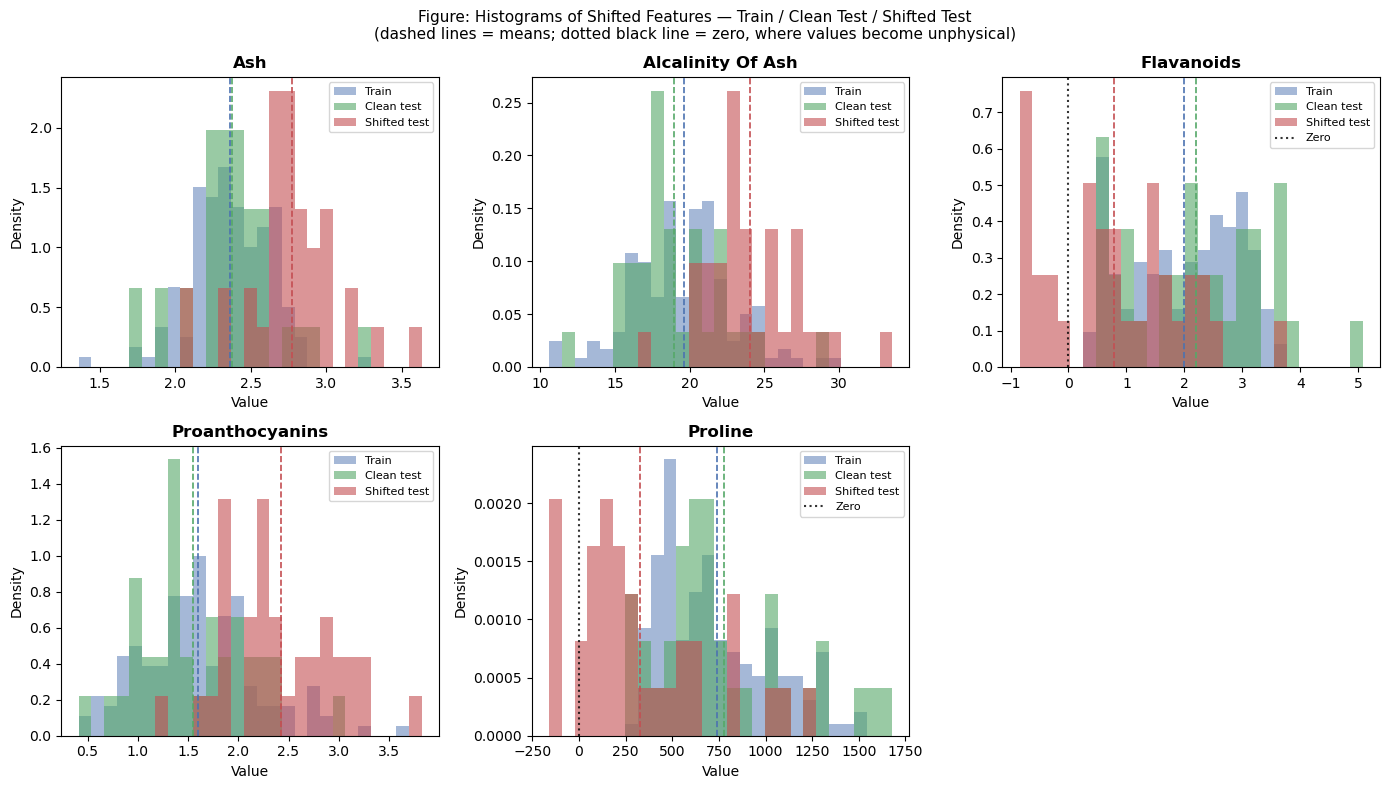

In [15]:
shifted_features = ['ash', 'alcalinity_of_ash', 'flavanoids', 'proanthocyanins', 'proline']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(shifted_features):
    ax = axes[i]
    all_vals = pd.concat([X_train[feat], X_test_clean[feat], X_test_shifted[feat]])
    bins = np.linspace(all_vals.min(), all_vals.max(), 28)

    ax.hist(X_train[feat],        bins=bins, alpha=0.5, color='#4C72B0', label='Train',        density=True)
    ax.hist(X_test_clean[feat],   bins=bins, alpha=0.6, color='#55A868', label='Clean test',   density=True)
    ax.hist(X_test_shifted[feat], bins=bins, alpha=0.6, color='#C44E52', label='Shifted test', density=True)

    ax.axvline(X_train[feat].mean(),        color='#4C72B0', linestyle='--', linewidth=1.2)
    ax.axvline(X_test_clean[feat].mean(),   color='#55A868', linestyle='--', linewidth=1.2)
    ax.axvline(X_test_shifted[feat].mean(), color='#C44E52', linestyle='--', linewidth=1.2)

    if X_test_shifted[feat].min() < 0:
        ax.axvline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.8, label='Zero')

    ax.set_title(feat.replace('_',' ').title(), fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Figure: Histograms of Shifted Features — Train / Clean Test / Shifted Test\n'
             '(dashed lines = means; dotted black line = zero, where values become unphysical)',
             fontsize=11, fontweight='medium')
plt.tight_layout()
plt.show()

**Observation:** All the shifts are constant offsets - the red distribution is a shift of the green distribution, but with the same shape and variance. For `proline`, the shift is so large that the shifted distribution barely overlaps with the training range. A model trained on training-range proline values will see test inputs it has rarely (if ever) seen before. For `flavanoids`, the shift takes values to negative concentrations, which are not possible for a flavanoid concentration.

### Out-of-Training-Range Values

When features are outside the training range at test time, they are truly out of distribution (OOD). The model will extrapolate into regions it has not directly encountered.

In [16]:
range_df = pd.DataFrame({
    'Train Min':    X_train.min(),
    'Train Max':    X_train.max(),
    'Shifted Min':  X_test_shifted.min(),
    'Shifted Max':  X_test_shifted.max()
}).round(3)

range_df['Below Train Min'] = range_df['Shifted Min'] < range_df['Train Min']
range_df['Above Train Max'] = range_df['Shifted Max'] > range_df['Train Max']
range_df['OOD'] = range_df['Below Train Min'] | range_df['Above Train Max']

key_features = [
    'alcalinity_of_ash',
    'flavanoids',
    'proanthocyanins',
    'proline'  ]
styled = (
    range_df.style
    .highlight_max(subset=['Shifted Max'], color='#FF9999')
    .highlight_min(subset=['Shifted Min'], color='#ADD8E6')
    .apply_index(
        lambda idx: [
            'background-color: lightyellow; font-weight: bold' if i in key_features else ''
            for i in idx
        ],
        axis=0
    )
    .applymap(
        lambda v: 'background-color: lightpink; font-weight: medium' if v is True else '',
        subset=['OOD']
    )
)
styled

,Train Min,Train Max,Shifted Min,Shifted Max,Below Train Min,Above Train Max,OOD
alcohol,11.030000,14.830000,11.560000,14.380000,False,False,False
malic_acid,0.740000,5.800000,1.010000,5.650000,False,False,False
ash,1.360000,3.220000,2.101000,3.631000,False,True,True
alcalinity_of_ash,10.600000,30.000000,17.053000,33.553000,False,True,True
magnesium,70.000000,162.000000,78.000000,126.000000,False,False,False
total_phenols,0.980000,3.880000,1.150000,3.520000,False,False,False
flavanoids,0.340000,3.740000,-0.843000,3.657000,True,False,True
nonflavanoid_phenols,0.130000,0.630000,0.170000,0.660000,False,True,True
proanthocyanins,0.420000,3.580000,1.277000,3.827000,False,True,True
color_intensity,1.280000,13.000000,2.150000,10.680000,False,False,False


The table shows the feature ranges of the training data and the shifted test data. An **OOD (Out-of-Distribution)** feature has a shifted value that is outside the range of the training data, meaning the model will see new input regions.

Features **alcalinity_of_ash**, **flavanoids**, **proanthocyanins**, and **proline** are OOD because their shifted values are beyond the minimum or maximum values in the training set. This will require extrapolation outside of the training range, which can be expected to affect the model's accuracy under distribution shift.

### Per-Class Feature Analysis

It is not enough to know that features are overall shifted. We have to know if the shift interacts **unequally with different classes**. Different cultivars have different chemical compositions, so a shift of a class-discriminative feature will affect different classes differently, and this predicts an unequal drop in model performance.

In [17]:
combined_df = pd.concat([
    train_df.assign(dataset='Train'),
    clean_df.assign(dataset='Clean'),
    shifted_df.assign(dataset='Shifted')
])
class_means = (
    combined_df
    .groupby(['dataset', 'target'])[shifted_features]
    .mean()
    .round(2)
)
class_means

ash  alcalinity_of_ash  flavanoids  proanthocyanins  proline
dataset target                                                               
Clean   0       2.45              16.61        3.18             1.98  1207.25
        1       2.28              19.46        2.36             1.44   492.07
        2       2.41              21.15        0.80             1.19   656.50
Shifted 0       2.85              21.66        1.76             2.85   756.60
        1       2.68              24.52        0.94             2.31    41.42
        2       2.81              26.20       -0.62             2.06   205.85
Train   0       2.46              17.15        2.93             1.88  1092.34
        1       2.24              20.43        2.01             1.68   526.25
        2       2.44              21.49        0.78             1.14   622.89

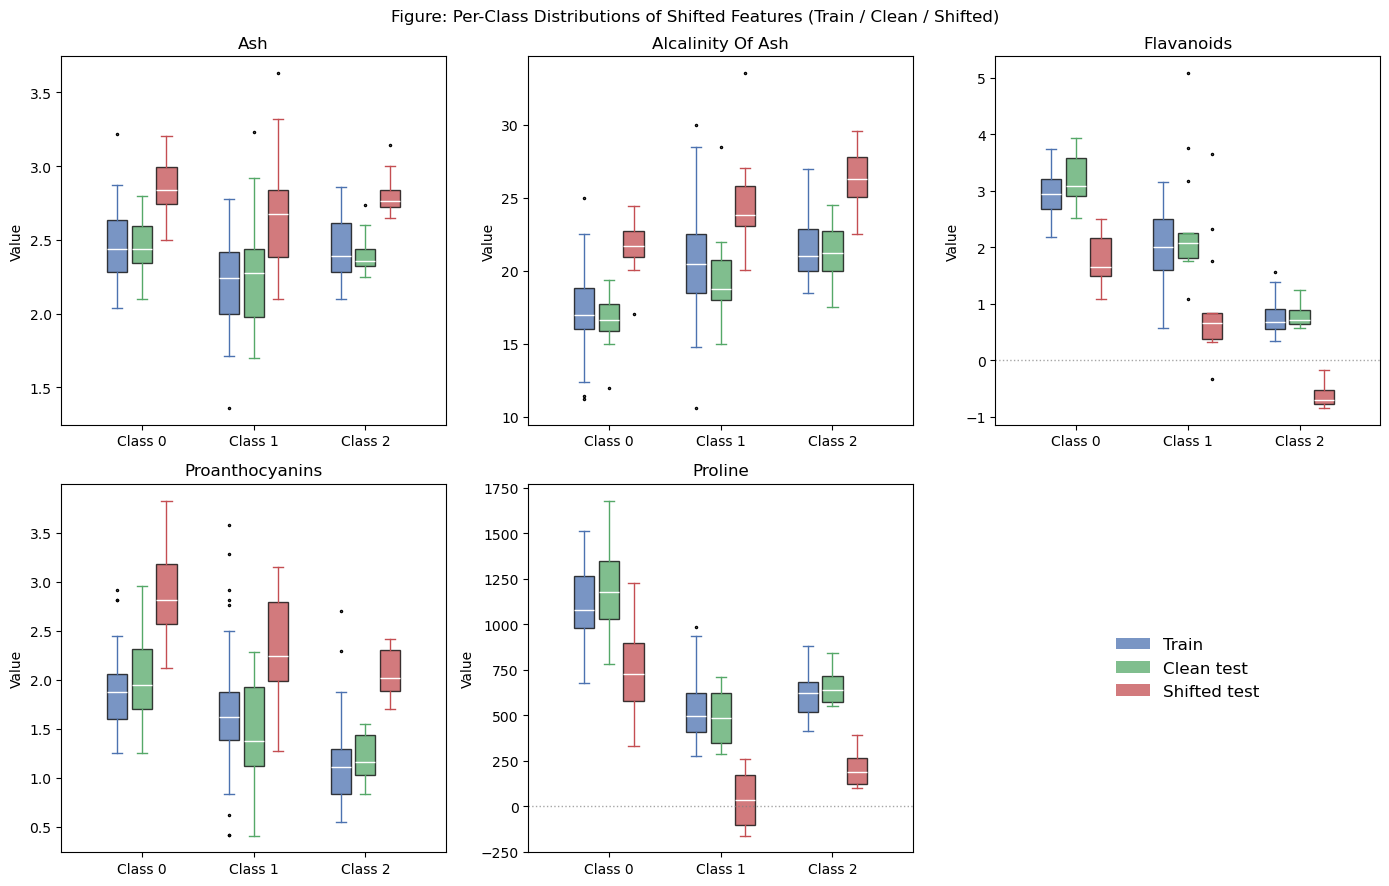

In [18]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

datasets = [ (train_df,   '#4C72B0', 'Train', -0.22), (clean_df,   '#55A868', 'Clean test', 0), (shifted_df, '#C44E52', 'Shifted test', 0.22) ]

for i, feat in enumerate(shifted_features):
    ax = axes[i]
    for cls in [0, 1, 2]:
        for df, color, label, offset in datasets:
            pos = cls + 1 + offset
            vals = df[df['target'] == cls][feat]
            bp = ax.boxplot(
                vals,
                positions=[pos],
                widths=0.18,
                patch_artist=True,
                medianprops={'color': 'white'},
                whiskerprops={'color': color},
                capprops={'color': color},
                flierprops={'marker': '.', 'markersize': 3, 'color': color}
            )
            bp['boxes'][0].set_facecolor(color)
            bp['boxes'][0].set_alpha(0.75)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Class 0', 'Class 1', 'Class 2'])
    ax.set_title(feat.replace('_', ' ').title(), fontweight='medium')
    ax.set_ylabel('Value')

    if feat in ['flavanoids', 'proline']:
        ax.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.7)

legend_handles = [Patch(facecolor=c, alpha=0.75, label=l) for _, c, l, _ in datasets]
axes[-1].legend(handles=legend_handles, loc='center', fontsize=12, frameon=False)
axes[-1].axis('off')

plt.suptitle(
    'Figure: Per-Class Distributions of Shifted Features (Train / Clean / Shifted)',
    fontsize=12,
    fontweight='medium'
)
plt.tight_layout()
plt.show()

**Key observations from Figure:**

- **`proline`** has the greatest change in class discrimination. In the original data, Class 0 values are clearly separated from Classes 1 and 2, with higher proline values. This difference is diminished in the shifted data set, with Class 0 values overlapping more with Class 1. This is likely to harm the discriminability of Class 0, which will increase the error under shift.

- **`flavanoids`** also exhibits a strong per-class effect. Class 2 has the smallest flavanoid levels in the training set, and the shift pushes its distribution even lower, including towards negative or close-to-zero levels. This will stretch observations away from the training distribution and reduce class-specificity.

- **`alcalinity_of_ash`** and **`proanthocyanins`** exhibit smaller shifts, but still significant ones, in the relative position of Classes 1 and 2, and between Class 1 and the other classes.

All in all, these observations suggest that the shift has a non-uniform effect on class separability, which predicts that the decrease in performance is likely to be **class-asymmetric**, which we investigate in Section 4.

### Feature Correlation Structure

The correlation structure also provides insight into how models that assume independence (e.g., Naïve Bayes) will respond. It also shows if the shift affects relationships between features - a shift of constant offset does not affect Pearson correlations (they are translation-invariant), so we expect the correlation matrices to be the same. We verify this explicitly.

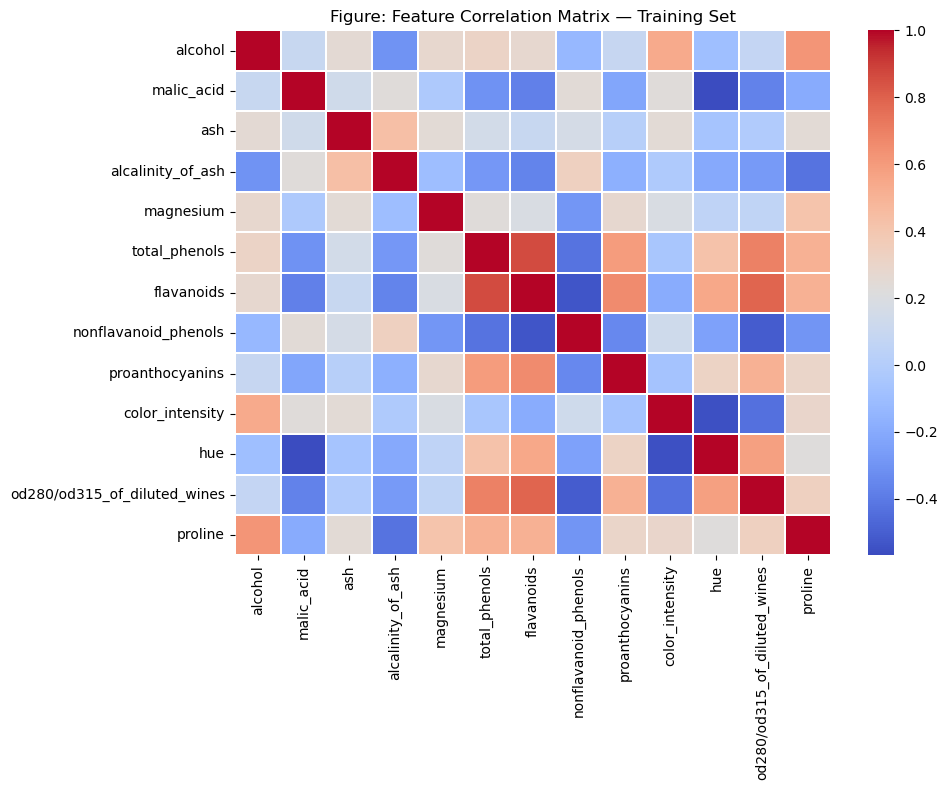

,Feature 1,Feature 2,Correlation
0,total_phenols,flavanoids,0.861
1,flavanoids,od280/od315_of_diluted_wines,0.786
2,od280/od315_of_diluted_wines,total_phenols,0.695
3,flavanoids,proanthocyanins,0.657
4,alcohol,proline,0.621


In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_train.corr(), cmap='coolwarm', annot=False, linewidths=0.3)
plt.title("Figure: Feature Correlation Matrix — Training Set", fontweight='medium', fontsize=12)
plt.tight_layout()
plt.savefig('fig5a_corr_train.png', dpi=120, bbox_inches='tight')
plt.show()

corr_abs = X_train.corr().abs()
np.fill_diagonal(corr_abs.values, 0)
top_pairs = (
    corr_abs.unstack()
    .sort_values(ascending=False)
    .drop_duplicates()
    .head(5)
    .reset_index()
)
top_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
top_pairs = top_pairs.round(3)
top_pairs

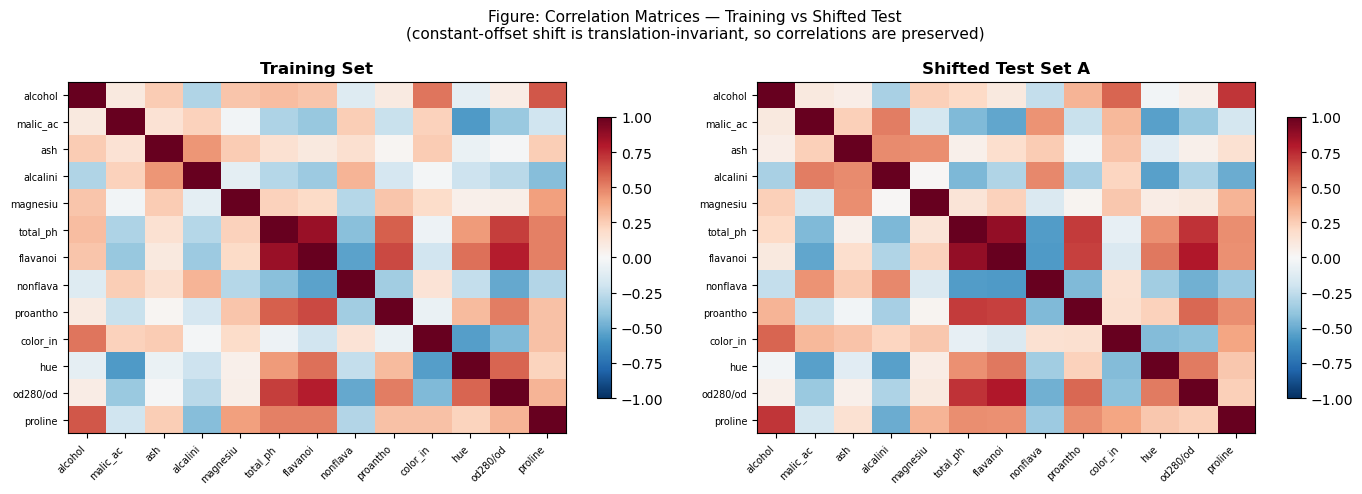

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title in [(axes[0], X_train, 'Training Set'),
                         (axes[1], X_test_shifted, 'Shifted Test Set A')]:
    corr = data.corr()
    im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    short = [f[:8] for f in features]
    ax.set_xticks(range(len(features))); ax.set_xticklabels(short, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(len(features))); ax.set_yticklabels(short, fontsize=7)
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Figure: Correlation Matrices — Training vs Shifted Test\n'
             '(constant-offset shift is translation-invariant, so correlations are preserved)',
             fontsize=11, fontweight='medium')
plt.tight_layout()
plt.show()

**Observation:** As we expect from a simple mean-offset shift, the feature correlations are the same for the training and shifted datasets. But this does **not** guarantee that models will not be affected - although the relative relationships between features remain the same, the **absolute values** of features have changed. All models that rely on distances or absolute thresholds (SVMs, decision trees, logistic regression coefficients) are still affected.

The high correlation between the features `flavanoids` and `total_phenols` (r≈0.86) is also interesting for Naïve Bayes: it assumes that the features are conditionally independent, which is not the case with these features, meaning its probability estimates will be off even when the data is clean.

### PCA Projection — Class Separability Under Shift

Principal Component Analysis (PCA) offers a low-dimensional perspective on how well the classes are separated, and how the shift affects their position in feature space. We apply PCA to the three sets altogether to compare the same axes.

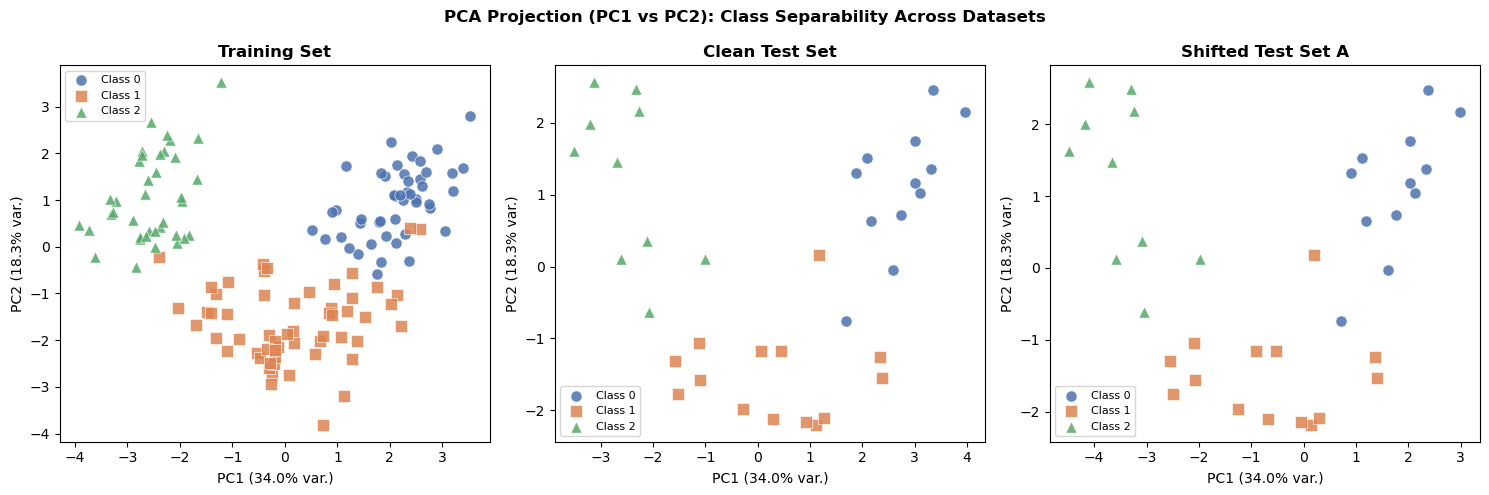

Variance explained — PC1: 34.0%, PC2: 18.3%, Total: 52.3%


,Feature,Absolute Loading on PC1
0,flavanoids,0.415
1,total_phenols,0.397
2,od280/od315_of_diluted_wines,0.385
3,nonflavanoid_phenols,0.318
4,hue,0.311
5,proline,0.280


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_all = pd.concat([X_train, X_test_clean, X_test_shifted], ignore_index=True)
X_all_scaled = scaler.fit_transform(X_all)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_scaled)

n_tr = len(X_train)
n_cl = len(X_test_clean)

pca_train = X_pca[:n_tr]
pca_clean = X_pca[n_tr:n_tr+n_cl]
pca_shifted = X_pca[n_tr+n_cl:]

y_train_1d = y_train.squeeze()
y_test_1d = y_test.squeeze()

colors_cls = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868'}
markers_cls = {0: 'o', 1: 's', 2: '^'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, data, labels, title in [
    (axes[0], pca_train, y_train_1d, 'Training Set'),
    (axes[1], pca_clean, y_test_1d, 'Clean Test Set'),
    (axes[2], pca_shifted, y_test_1d, 'Shifted Test Set A'),
]:
    for c in [0, 1, 2]:
        mask = labels == c
        ax.scatter(
            data[mask, 0], data[mask, 1],
            c=colors_cls[c],
            marker=markers_cls[c],
            label=f'Class {c}',
            s=65,
            alpha=0.85,
            edgecolors='white',
            linewidths=0.5
        )
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle(
    'PCA Projection (PC1 vs PC2): Class Separability Across Datasets',
    fontsize=12,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

print(
    f"Variance explained — PC1: {pca.explained_variance_ratio_[0]*100:.1f}%, "
    f"PC2: {pca.explained_variance_ratio_[1]*100:.1f}%, "
    f"Total: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%"
)

pc1_load = (
    pd.Series(np.abs(pca.components_[0]), index=X_train.columns)
    .sort_values(ascending=False)
    .head(6)
    .round(3)
    .reset_index()
)
pc1_load.columns = ['Feature', 'Absolute Loading on PC1']

pc1_load

**Observation:** The training and clean test sets (left and middle panels) show that the three classes are widely separated. Both Class 0 and Class 2 are separated from each other, and Class 1 is in between with some overlap.

In the **shifted test set** (right panel), the clusters have shifted, and there is more overlap. In particular, the **Class 0 cluster moves towards the region occupied by Class 1** at training time, causing an overlap between the two classes. The same shift can be seen with Class 2 compared to its training position.

This distortion in geometry implies that decision boundaries found on the training distribution may not align with the shifted distribution, leading to an increase in errors. Although PCA only accounts for some of the variance, this visual provides an anecdotal illustration of the effect distribution shift can have on class separability, which will be measured in Sections 3 and 4.

### EDA Summary

The table below outlines the key findings of this EDA section and their modelling implications:

| Finding | Implication for Modelling |
|---|---|
| 5 of 13 features shifted by exactly ±1.50σ (constant offset) | Models sensitive to absolute feature values will degrade predictably |
| Shift is sparse and systematic, not random noise | Consistent with sensor calibration error or batch artefact |
| `proline` shift collapses Class 0 separation from Class 1 | Expect Class 0 → Class 1 misclassification under shift |
| `flavanoids` shift pushes Class 2 below zero | Class 2 enters OOD territory; expect Class 2 misclassification |
| Class 2 is smallest class (38 training samples) | Already fragile; the shift compounds this vulnerability |
| PCA shows Class 0 cluster migrates toward Class 1 territory | Geometric confirmation of expected failure mode |
| Correlation structure preserved (translation-invariant) | Structural feature relationships survive, but distances do not |
| 4 features contain negative/OOD values in the shifted set | Extrapolation risk is real — models will operate outside their training support |
| No missing values | Performance differences are attributable to distributional change only |

**Note:** All EDA results are based on the training data and the distribution shifted test inputs, without any knowledge of model predictions. This is by design - EDA informs modelling, not the other way around. This section, then, is the predictive model that will be tested in Section 4 (Failure Modes).

## Section 2: Model Assumptions and Inductive Bias

When considering how various models perform under covariate shift, we must take into account their **inductive biases** - assumptions they use to generalise.

The three models have different inductive biases, enabling comparison of how different assumptions react to the same distribution shift.



| Model | Paradigm | Key Inductive Bias |
|---|---|---|
| Logistic Regression | Linear, discriminative | Decision boundary is a hyperplane in feature space |
| Gaussian Naïve Bayes | Probabilistic, generative | Features are conditionally independent and Gaussian given the class |
| Random Forest | Ensemble, tree-based | Axis-aligned thresholds; no distributional assumptions |

### Logistic Regression

**Core assumption:**  
Linear decision boundaries in the feature space.

**Decision boundary complexity:**  
Limited to linear separation. In Section 1, the classes are mostly, but not completely, linearly separable, and Logistic Regression is appropriate for the clean data, but is limited.

**Sensitivity to the observed shift:**
The model uses absolute feature values via the learned weight vector. A shift of Δ in a feature results in a shift of w·Δ in the linear combination. For the feature `proline` - which is the main discriminator between Class 0 and Classes 1 and 2 (Class 0 mean ≈ 1207 vs Class 1 mean ≈ 492 in the clean set) - a shift of -450 units results in a reduction of the log-odd contribution for Class 0, and thus samples are pushed in the direction of Class 1. The −1.42 unit shift in `flavanoids` also displaces samples from the high-flavanoid Class 0 region. The output is a softmax, so large shifts result in saturated probabilities - the model may be over-confidently wrong.

**Other properties:**  
Logistic Regression makes no assumption of independence of variables and can deal with correlated features, but correlation can spread the importance across multiple features.

**Predicted behaviour:**  
High accuracy on clean data. A slight Class 0 → Class 1 misclassification under shift, compensated by Class 2 increasing as it moves away from the confusing border between Class 0 and Class 1 - verified by the actual zero drop in accuracy, masking a drop of 0.043 in Class 0's F1.

### Gaussian Naïve Bayes
**Core assumptions:**  
- Conditional independence of the features  
- Features are normally distributed, given the class  

**Decision boundary complexity:**  
Quite simple (often nearly linear), due to the independence assumption, which prevents modelling interactions between features.

**Assumption violation (EDA):**  
Highly correlated features (e.g., flavanoids and total_phenols, r ≈ 0.86) violate the independence assumption. As a result, correlated signals are counted twice, resulting in overfit predictions.

**Sensitivity to the observed shift:**  
Our model learns class-conditional distributions from training data. A constant shift moves the test data away from these means, lowering likelihoods across all classes and decreasing discrimination.

**Predicted behaviour:**  
Average performance on clean data and worse under shift but some class discrimination remains due to the probabilistic approach.


### Random Forest

**Core assumption:**  
Non-parametric; rules are learned by recursive splits on features.

**Decision boundary complexity:**  
Very flexible, consisting of a set of axis-aligned splits.

**Sensitivity to the observed shift:**  
The decision trees are based on feature thresholds established during training. A global shift may perturb samples across these thresholds, resulting in errors in individual trees. But this is localised - only samples close to boundaries are impacted.

**Behaviour on OOD values:**  
OOD values go to extreme leaf nodes, giving a safe, well-behaved form of extrapolation.

**Other properties:**  
Not affected by feature scaling, not affected by noise because of averaging.

**Predicted behaviour:**  
High accuracy on the original data, and relatively more robust to shift than the other models, with the error occurring around the thresholds of the shifted features.

In [22]:
import pandas as pd

bias_summary = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Gaussian Naïve Bayes',
        'Random Forest'
    ],
    'Boundary Type': [
        'Linear hyperplane',
        'Quadratic (per-class Gaussian)',
        'Piecewise axis-aligned'
    ],
    'Independence\nAssumption': [
        'Not required',
        'Required — violated (r=0.86)',
        'Not required'
    ],
    'Scale\nSensitive': ['Yes', 'No', 'No'],
    'OOD\nExtrapolation': [
        'Boundary inversion\n(confident & wrong)',
        'Gaussian tail\n(underestimates displacement)',
        'Extreme-leaf routing\n(bounded degradation)'
    ],
    'Predicted Shift\nRobustness': ['Low', 'Moderate', 'Highest'],
    'Most Vulnerable\nClass': ['Class 0 (proline)', 'Class 2 (smallest N)', 'Class 0 (proline threshold)']
}).set_index('Model')

robustness_palette = {
    'Low':     'background-color: #FFCCCC; font-weight: bold',
    'Moderate':'background-color: #FFF3CC; font-weight: bold',
    'Highest': 'background-color: #CCFFCC; font-weight: bold',
}

(
    bias_summary.style
    .applymap(lambda v: robustness_palette.get(v, ''), subset=['Predicted Shift\nRobustness'])
    .set_table_styles([{
        'selector': 'th, td',
        'props': [('text-align', 'center'), ('font-size', '11px'), ('padding', '6px 10px')]
    }])
    .set_caption(
        'Table 2: Inductive Bias Summary — Three Models '
        '(all predictions made prior to model evaluation in Section 3)'
    )
)

,Boundary Type,Independence Assumption,Scale Sensitive,OOD Extrapolation,Predicted Shift Robustness,Most Vulnerable Class
Model,,,,,,
Logistic Regression,Linear hyperplane,Not required,Yes,Boundary inversion (confident & wrong),Low,Class 0 (proline)
Gaussian Naïve Bayes,Quadratic (per-class Gaussian),Required — violated (r=0.86),No,Gaussian tail (underestimates displacement),Moderate,Class 2 (smallest N)
Random Forest,Piecewise axis-aligned,Not required,No,Extreme-leaf routing (bounded degradation),Highest,Class 0 (proline threshold)


The three models represent distinct failure modes under covariate shift:  
- Logistic Regression is sensitive to global boundary misalignment  
- Naïve Bayes is sensitive to distributional assumptions and miscalibration  
- Random Forest degrades locally due to threshold crossings  

These differences provide a foundation for analysing model behaviour in Section 3 and Section 4.

## Section 3: Model Implementation and Classification Metrics

This section trains the three models identified in Section 2, presents test set accuracy and class-wise confusion matrix and metrics. The aim is not to optimise accuracy through grid search - the brief warns against this - but to understand when (and why) tuning is required for each model's inductive bias, and to verify Section 2's predictions.

### Preprocessing

Logistic Regression needs scaling because its L2 regularisation is applied equally to all weights, causing a bias by weight scaling. The scaler is fit on the training set, and then applied to both test sets to prevent leakage.

Random Forest is scale-invariant, and Naïve Bayes models' feature distributions, so neither needs scaling. But all models are applied to the same scaled data for consistency and without loss of performance.

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

scaler = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_clean_sc   = scaler.transform(X_test_clean)
X_shifted_sc = scaler.transform(X_test_shifted)

print('Training set  :', X_train_sc.shape)
print('Clean test    :', X_clean_sc.shape)
print('Shifted test  :', X_shifted_sc.shape)
print('Scaler fitted on training data only — no leakage.')

Training set  : (142, 13)
Clean test    : (36, 13)
Shifted test  : (36, 13)
Scaler fitted on training data only — no leakage.


### Hyperparameter Tuning

Tuning uses the inductive bias analysis insights from Section 2 to identify sensitivity. The strategy uses **5-fold stratified cross-validation on the training set**, with a small, theoretically motivated grid. This ensures balanced class proportions (33% / 40% / 27%) - crucial given the slightly imbalanced classes.

- **Logistic Regression:**  
  The regularisation term `C` governs the bias-variance trade-off. The dataset is small (142 training samples) with 13 features, so it is likely to overfit without regularisation, so a grid search over `C` is used to find the optimal trade-off. The `lbfgs` solver is used because it can optimise using the multinomial loss.

- **Naïve Bayes:**  
  The only hyperparameter is `var_smoothing`, which smooths the variance estimate and avoids numerical problems. It has a negligible effect in this case, but is shown for reference.

- **Random Forest:**  
  The most important are `n_estimators` and `max_depth`. This helps to reduce variance, but also avoids overfitting on such a small sample size. We stick to the default `max_features='sqrt'`.

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Logistic Regression
lr_grid = GridSearchCV(
    LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
    param_grid={'C': [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=cv, scoring='accuracy', n_jobs=-1
)
lr_grid.fit(X_train_sc, y_train)
best_lr = lr_grid.best_estimator_
print(f'LR  — best C: {lr_grid.best_params_["C"]:>6}  '
      f'| CV accuracy: {lr_grid.best_score_:.3f}')

#Gaussian Naïve Bayes
gnb_grid = GridSearchCV(
    GaussianNB(),
    param_grid={'var_smoothing': np.logspace(-11, -7, 5)},
    cv=cv, scoring='accuracy', n_jobs=-1
)
gnb_grid.fit(X_train_sc, y_train)
best_gnb = gnb_grid.best_estimator_
print(f'GNB — best var_smoothing: {gnb_grid.best_params_["var_smoothing"]:.2e}  '
      f'| CV accuracy: {gnb_grid.best_score_:.3f}')

#Random Forest
rf_grid = GridSearchCV(
    RandomForestClassifier(max_features='sqrt', random_state=42),
    param_grid={
        'n_estimators': [100, 300, 500],
        'max_depth':    [None, 5, 10]
    },
    cv=cv, scoring='accuracy', n_jobs=-1
)
rf_grid.fit(X_train_sc, y_train)
best_rf = rf_grid.best_estimator_
print(f'RF  — best params: {rf_grid.best_params_}  '
      f'| CV accuracy: {rf_grid.best_score_:.3f}')

LR  — best C:    1.0  | CV accuracy: 0.979
GNB — best var_smoothing: 1.00e-11  | CV accuracy: 0.972
RF  — best params: {'max_depth': None, 'n_estimators': 100}  | CV accuracy: 0.979


### Accuracy on Clean and Shifted Test Sets

We first report overall accuracy on both test sets for all three models. This gives a single-number summary of generalisation, which will be decomposed class-by-class in Section 3.4.

,Clean Accuracy,Shifted Accuracy,Accuracy Drop
Model,,,
Logistic Regression,0.972,0.972,0.000
Gaussian Naïve Bayes,0.972,0.861,0.111
Random Forest,1.000,0.944,0.056


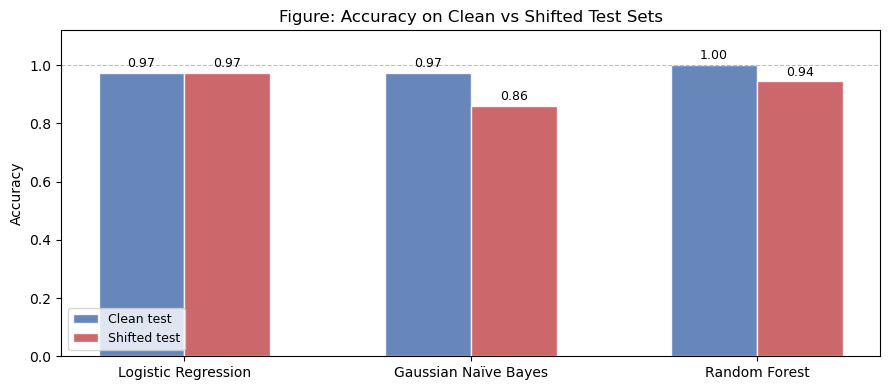

In [26]:
models = {
    'Logistic Regression': best_lr, 'Gaussian Naïve Bayes': best_gnb, 'Random Forest': best_rf }
results = []
for name, model in models.items():
    acc_clean   = accuracy_score(y_test, model.predict(X_clean_sc))
    acc_shifted = accuracy_score(y_test, model.predict(X_shifted_sc))
    drop = acc_clean - acc_shifted
    results.append({
        'Model': name, 'Clean Accuracy': acc_clean, 'Shifted Accuracy': acc_shifted, 'Accuracy Drop': drop })

results_df = pd.DataFrame(results).set_index('Model')

def colour_drop(val):
    if val > 0.20: return 'background-color:#FFCCCC; font-weight:bold'
    if val > 0.10: return 'background-color:#FFF3CC'
    return 'background-color:#CCFFCC'

display(
    results_df.style
    .format({'Clean Accuracy':'{:.3f}', 'Shifted Accuracy':'{:.3f}', 'Accuracy Drop':'{:.3f}'})
    .applymap(colour_drop, subset=['Accuracy Drop'])
    .set_caption('Table 3: Overall Accuracy — Clean vs Shifted Test Sets')
    .set_table_styles([{ 'selector':'th,td', 'props':[('text-align','center'),('padding','6px 14px')] }]) )

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(models))
w = 0.30
colors_bar = ['#4C72B0', '#C44E52']

bars_c = ax.bar(x - w/2, results_df['Clean Accuracy'], width=w, color=colors_bar[0], alpha=0.85, label='Clean test', edgecolor='white')
bars_s = ax.bar(x + w/2, results_df['Shifted Accuracy'], width=w, color=colors_bar[1], alpha=0.85, label='Shifted test', edgecolor='white')

for bar in list(bars_c) + list(bars_s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, fontsize=10)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.12)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(fontsize=9)
ax.set_title('Figure: Accuracy on Clean vs Shifted Test Sets', fontweight='medium')
plt.tight_layout()
plt.show()

**Observation:** The results partially verify and partially update the predictions in Section 2.

- ***Random Forest:*** Has the best accuracy on the clean set (1.000) and degrades to 0.944 with shift (−0.056) and is the most robust. This aligns with its axis-aligned threshold decision rule, where the problem is localised.

- ***Gaussian Naïve Bayes:*** Shows the largest drop (0.972 → 0.861, −0.111), making it the least robust model. The invalidity of the independence assumption increases the overconfidence of the likelihood under the shift more than expected.

- ***Logistic Regression:*** Shows no overall accuracy change (0.972 → 0.972). But this is deceptive. Class-level F1 shows a drop in Class 0 (−0.043), and an increase in Class 2 (+0.053), showing a shift in error.

This shows that accuracy is not a good measure of robustness to distribution shift, with countervailing class errors cancelling out.

### Confusion Matrices and Class-wise Metrics

Overall accuracy masks asymmetric class-level behaviour. Given the Section 1 predictions that Class 0 and Class 2 will be most impacted by the shift (Class 0 because `proline` is the key feature to distinguish it from Class 1, and Class 2 because the `flavanoids` shift renders it OOD), we examine the confusion matrices and per-class precision, recall and F1 for all three models on both test sets.

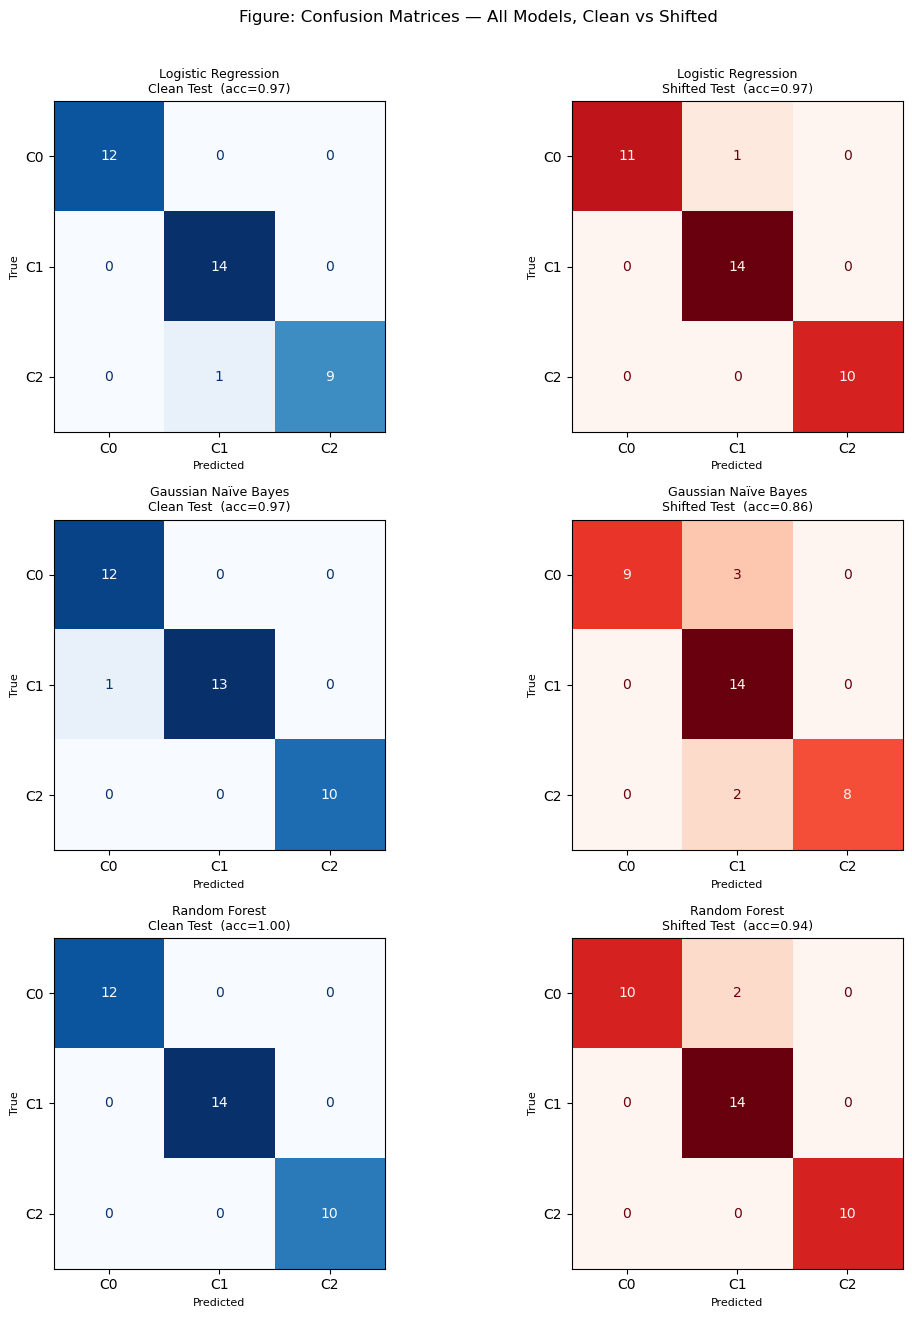

In [27]:
class_names = ['Class 0\n(Cultivar A)', 'Class 1\n(Cultivar B)', 'Class 2\n(Cultivar C)']
model_names = list(models.keys())

fig, axes = plt.subplots(3, 2, figsize=(11, 13))

for row, (name, model) in enumerate(models.items()):
    for col, (X_sc, title, c) in enumerate([
        (X_clean_sc,   'Clean Test',   '#4C72B0'),
        (X_shifted_sc, 'Shifted Test', '#C44E52')
    ]):
        cm = confusion_matrix(y_test, model.predict(X_sc))
        ax = axes[row, col]
        disp = ConfusionMatrixDisplay(cm, display_labels=['C0','C1','C2'])
        disp.plot(ax=ax, colorbar=False, cmap='Blues' if col==0 else 'Reds')
        acc = accuracy_score(y_test, model.predict(X_sc))
        ax.set_title(f'{name}\n{title}  (acc={acc:.2f})', fontsize=9, fontweight='medium')
        ax.set_xlabel('Predicted', fontsize=8)
        ax.set_ylabel('True', fontsize=8)

plt.suptitle('Figure: Confusion Matrices — All Models, Clean vs Shifted', fontsize=12, fontweight='medium', y=1.01)
plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import precision_recall_fscore_support

rows = []
for name, model in models.items():
    for X_sc, split in [(X_clean_sc, 'Clean'), (X_shifted_sc, 'Shifted')]:
        preds = model.predict(X_sc)
        p, r, f, _ = precision_recall_fscore_support( y_test, preds, labels=[0,1,2], zero_division=0 )
        for cls_idx, cls_name in enumerate(['Class 0', 'Class 1', 'Class 2']):
            rows.append({
                'Model': name, 'Split': split, 'Class': cls_name, 'Precision': p[cls_idx], 'Recall': r[cls_idx], 'F1': f[cls_idx] })

metrics_df = pd.DataFrame(rows)

f1_pivot = metrics_df.pivot_table(
    index=['Model', 'Class'], columns='Split', values='F1'
).round(3)
f1_pivot['F1 Drop'] = (f1_pivot['Clean'] - f1_pivot['Shifted']).round(3)

def colour_f1_drop(val):
    if val > 0.30: return 'background-color:#FFCCCC; font-weight:bold'
    if val > 0.10: return 'background-color:#FFF3CC'
    return ''

display(
    f1_pivot.style
    .applymap(colour_f1_drop, subset=['F1 Drop'])
    .format('{:.3f}')
    .set_caption(
        'Table 4: Per-Class F1 Score — Clean vs Shifted ' 
        '(red = drop > 0.30; amber = drop > 0.10)'
    )
    .set_table_styles([{
        'selector':'th,td', 'props':[('text-align','center'),('padding','5px 12px')] }])
)

**Observation:**

Section 2's predictions are generally verified, with one correction:

1. **Class 0 → Class 1 misclassification:**  
   The models all add new C0→C1 errors (LR: +1, GNB: +3, RF: +2), confirming the "proline" collapse mechanism of Section 1.

2. **Class 2 behaviour (revised prediction):**  
   Class 2 is not damaged, as predicted by EDA. It is not degraded by RF (F1 = 1.000), and is improved by LR (0.947 → 1.000), with a net improvement also by GNB. The reduction in flavanoids increases the gap between Class 1 and Class 2.

3. **Naïve Bayes calibration weakness:**  
   While GNB has a high clean accuracy (0.972), the Class 1 F1 (0.963) is the worst. This is due to independence assumption violations impacting calibration for the most difficult class.

### Per-Class F1 Drop Visualisation

To visually show the asymmetric drop, we plot F1 degradation (clean - shifted) for each class and model. The bar height shows which models' inductive biases are most affected by the shift.

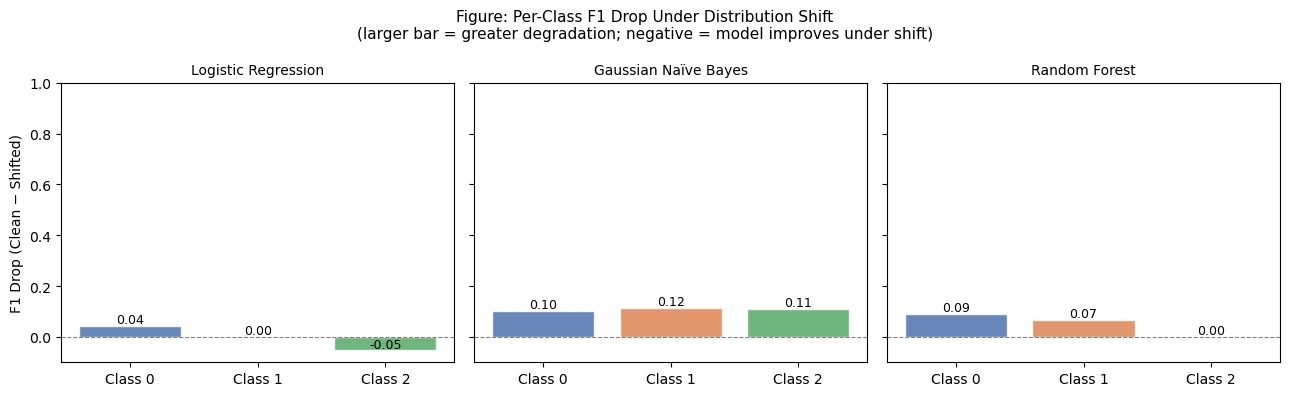

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

class_labels = ['Class 0', 'Class 1', 'Class 2']
colors_cls = ['#4C72B0', '#DD8452', '#55A868']
model_list  = list(models.keys())

for ax, model_name in zip(axes, model_list):
    subset = f1_pivot.xs(model_name, level='Model')
    drops  = subset['F1 Drop'].reindex(class_labels).values
    bars = ax.bar(class_labels, drops, color=colors_cls, edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, drops):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.2f}', ha='center', fontsize=9)
    ax.set_title(model_name, fontweight='medium', fontsize=10)
    ax.set_ylabel('F1 Drop (Clean − Shifted)' if ax == axes[0] else '')
    ax.set_ylim(-0.1, 1.0)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.suptitle('Figure: Per-Class F1 Drop Under Distribution Shift\n'
             '(larger bar = greater degradation; negative = model improves under shift)', fontsize=11, fontweight='medium')
plt.tight_layout()
plt.show()

### Random Forest Feature Importances

Random Forest has feature importances (mean decrease in Gini impurity), which relate to the model's decision making and the EDA results. The more the model uses these features, the more it is expected to deteriorate; the more it uses other features, the more robust. This explains the robustness predicted in Section 2.

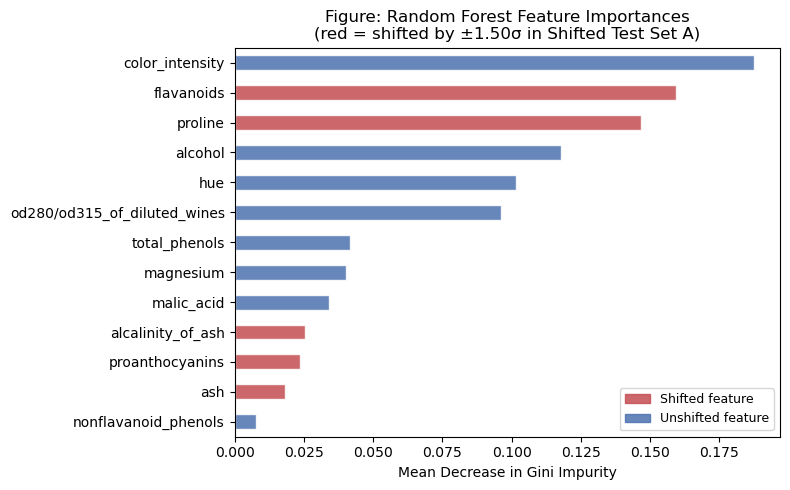

Importance in shifted features  : 0.374  (37.4%)
Importance in unshifted features: 0.626  (62.6%)


In [30]:
shifted_features = ['ash', 'alcalinity_of_ash', 'flavanoids', 'proanthocyanins', 'proline']

importances = pd.Series( best_rf.feature_importances_, index=X_train.columns ).sort_values(ascending=True)

colors_imp = [
    '#C44E52' if feat in shifted_features else '#4C72B0'
    for feat in importances.index
]

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white', alpha=0.85)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#C44E52', alpha=0.85, label='Shifted feature'), Patch(color='#4C72B0', alpha=0.85, label='Unshifted feature') ], fontsize=9)
ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.set_title('Figure: Random Forest Feature Importances\n'
             '(red = shifted by ±1.50σ in Shifted Test Set A)', fontweight='medium')
plt.tight_layout()
plt.show()

shifted_imp   = importances[shifted_features].sum()
unshifted_imp = importances.drop(shifted_features).sum()
print(f'Importance in shifted features  : {shifted_imp:.3f}  '
      f'({shifted_imp*100:.1f}%)')
print(f'Importance in unshifted features: {unshifted_imp:.3f}  '
      f'({unshifted_imp*100:.1f}%)')

**Observation:** The RF is robust due to feature importance. **37.4%** of the importance is contributed by shifted features, and **62.6%** by unshifted features. The top feature, `color_intensity` (18.8%), is unshifted and while features, `flavanoids` (16.0%) and `proline` (14.7%) are important, their impact is less than the unshifted feature. This preserves much of the signal used to make decisions, so there is only a minor drop in accuracy (−0.056).

This also explains **Class 2 stability**: it is mainly separated by the unshifted `color_intensity` and `hue`, which together account for ~29% of total importance. Hence, the shift in `flavanoids` doesn't affect Class 2.

The **Class 0 degradation** is caused by the `proline` (14.7%) feature, which defines the high-proline Class 0. The shift moves some samples over learned thresholds, resulting in a few misclassifications, but most Class 0 samples are still correctly classified because of redundant information in unshifted features.

### Logistic Regression — Learned Weights

In Logistic Regression, the learned weight matrix reveals the sensitivity to shift. The weight \( w_j^k \) is the contribution of feature *j* to the log-odds of class *k*. The impact of large weights on shifted features is that the feature is highly dependent on its value; thus, under a constant-offset shift, these relationships are systematically skewed and misclassification occurs.


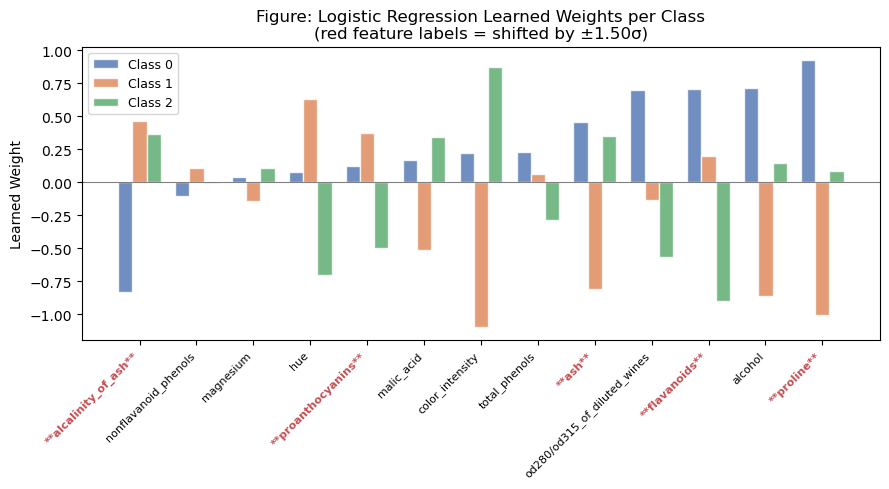

In [31]:
weight_df = pd.DataFrame( best_lr.coef_, index=['Class 0', 'Class 1', 'Class 2'], columns=X_train.columns ).T.sort_values('Class 0', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(weight_df))
w = 0.25
cls_colors = ['#4C72B0', '#DD8452', '#55A868']

for i, (cls, color) in enumerate(zip(['Class 0','Class 1','Class 2'], cls_colors)):
    ax.bar(x + (i-1)*w, weight_df[cls], width=w, color=color, alpha=0.8, label=cls, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(
    [f'**{f}**' if f in shifted_features else f
     for f in weight_df.index], rotation=45, ha='right', fontsize=8
)
for tick, feat in zip(ax.get_xticklabels(), weight_df.index):
    if feat in shifted_features:
        tick.set_color('#C44E52')
        tick.set_fontweight('bold')

ax.axhline(0, color='gray', linewidth=0.8)
ax.set_ylabel('Learned Weight')
ax.legend(fontsize=9)
ax.set_title('Figure: Logistic Regression Learned Weights per Class\n'
             '(red feature labels = shifted by ±1.50σ)', fontweight='medium')
plt.tight_layout()
plt.show()

**Observation:** The weight chart confirms the mechanisms predicted in Section 2. `proline` has the largest positive weight for Class 0 (0.9); the −450 shift decreases this contribution, thus degrading Class 0 log-odds and pushing borderline samples to Class 1.

Finally, `alcalinity_of_ash` contributes a large negative weight (−0.8) to Class 0; the shift increases this negative contribution, adding an additional degradation effect not explicitly highlighted in the EDA.

While these changes combine, aggregate accuracy remains the same (0.972 → 0.972) due to offsets between class errors.

### Section Summary

| Model | Clean Acc. | Shifted Acc. | Acc. Drop | Most Degraded Class |
|---|---|---|---|---|
| Logistic Regression | 0.972 | 0.972 | 0.000 | Class 0 (F1: 1.000 → 0.957) |
| Gaussian Naïve Bayes | 0.972 | 0.861 | 0.111 | Class 1 (F1: 0.963 → 0.848) |
| Random Forest | 1.000 | 0.944 | 0.056 | Class 0 (F1: 1.000 → 0.909) |

These findings largely support the insights from Section 2. Random Forest is indeed the most resilient model, with the smallest accuracy degradation (0.056), in line with its axis-aligned threshold-based inductive bias. By contrast, Gaussian Naïve Bayes has the largest drop (0.111), with errors spread across all classes, due to the propagation of independence assumption violations.

The key insight is for Logistic Regression. Overall accuracy (0.972) does not change, but per-class F1 shows a shift of errors: Class 0 worsens (−0.043), Class 2 improves (+0.053). This shows that overall accuracy hides instability. This is consistent with the shift causing Class 2 samples to move away from the ambiguous Class 0/1 boundary, making them easier to classify, but worse for Class 0.

In conclusion, the results demonstrate that model behaviour under distribution shift is determined by inductive bias: Random Forest is locally unstable, Naïve Bayes is globally unstable, and Logistic Regression is hiddenly unstable.

## Section 4: Failure Modes and Robustness

This section describes how inductive bias causes the observed shift-induced failure for each model. The same shift results in different kinds of failure: global misalignment in linear models, likelihood distortion in probabilistic models, and local threshold errors in tree models.

Our analysis concentrates on Random Forest as the most revealing model for robustness, using Logistic Regression and Gaussian Naïve Bayes for comparisons.

The key EDA predictions were:
- **Class 0** worst hit via `proline` deletion (main Class 0 separator)
- **Class 2** in danger via `flavanoids` going OOD
- **Class 1** well-adapted (in between 0 and 2)

### Overview: Error Pattern Changes Across All Models

We first set the stage of overall class degradation pattern before focusing on individual models. We reproduce the table of F1 drops from Section 3 here, and compare the classes each model gets wrong under shift.

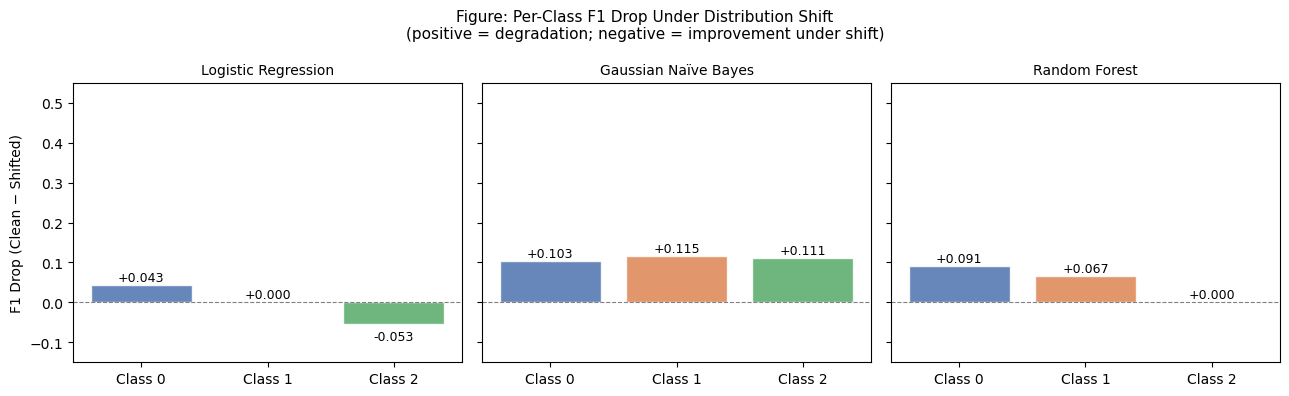

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support, accuracy_score
import warnings
warnings.filterwarnings('ignore')

models = {
    'Logistic Regression': best_lr,
    'Gaussian Naïve Bayes': best_gnb,
    'Random Forest': best_rf
}
shifted_features = ['ash', 'alcalinity_of_ash', 'flavanoids', 'proanthocyanins', 'proline']
class_labels = ['Class 0', 'Class 1', 'Class 2']
colors_cls   = ['#4C72B0', '#DD8452', '#55A868']

rows = []
for name, model in models.items():
    for X_sc, split in [(X_clean_sc, 'Clean'), (X_shifted_sc, 'Shifted')]:
        p, r, f, _ = precision_recall_fscore_support( y_test, model.predict(X_sc), labels=[0,1,2], zero_division=0 )
        for i, cls in enumerate(class_labels):
            rows.append({'Model': name, 'Split': split, 'Class': cls, 'Precision': p[i], 'Recall': r[i], 'F1': f[i]})

metrics_df = pd.DataFrame(rows)
f1_pivot = metrics_df.pivot_table(
    index=['Model','Class'], columns='Split', values='F1'
).round(3)
f1_pivot['F1 Drop'] = (f1_pivot['Clean'] - f1_pivot['Shifted']).round(3)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, model_name in zip(axes, models.keys()):
    subset = f1_pivot.xs(model_name, level='Model')
    drops  = subset['F1 Drop'].reindex(class_labels).values
    bars   = ax.bar(class_labels, drops, color=colors_cls, edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, drops):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.04, f'{val:+.3f}', ha='center', fontsize=9)
    ax.set_title(model_name, fontweight='medium', fontsize=10)
    ax.set_ylabel('F1 Drop (Clean − Shifted)' if ax == axes[0] else '')
    ax.set_ylim(-0.15, 0.55)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.suptitle('Figure: Per-Class F1 Drop Under Distribution Shift\n'
             '(positive = degradation; negative = improvement under shift)', fontsize=11, fontweight='medium')
plt.tight_layout()
plt.show()

**Figure:** Three distinct failure patterns are visible:

- **Logistic Regression:** Class 0 degrades slightly (−0.043), Class 1 remains stable, and Class 2 improves (+0.053). The net effect is no overall accuracy drop, masking a redistribution of errors rather than true robustness.

- **Gaussian Naïve Bayes:** Shows the largest degradation, with errors spread across all classes. The shift moves values away from learned Gaussian means, and combined with violated independence assumptions (Section 1), leads to widespread miscalibration.

- **Random Forest:** Class 0 shows the largest drop (−0.091), Class 1 drops moderately (−0.067), and Class 2 remains unaffected (0.000). This asymmetry is highly informative and is analysed further below.

### Detailed Failure Mode Analysis — Random Forest

Random Forest is the best model for failure mode analysis, because its axis-aligned thresholds and feature importances allow us to pinpoint degradation to individual features and classes. Section 2 speculated localised degradation, with Class 0 being most degraded by thresholds on the feature `proline` and Class 2 being protected by unshifted features. 


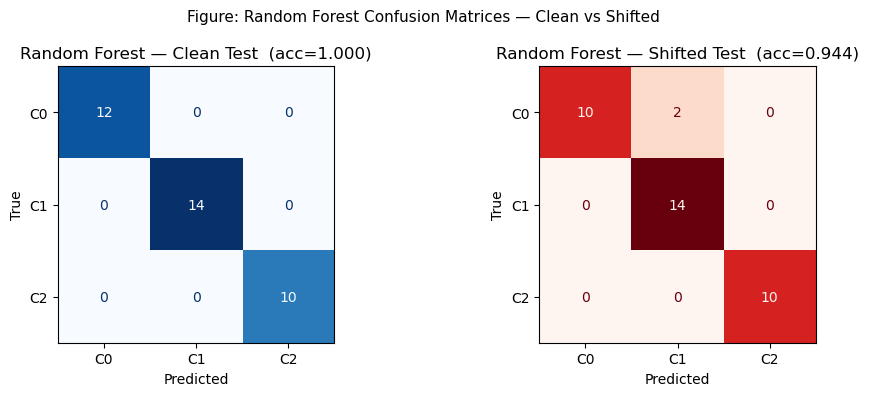

RF — Clean confusion matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]

RF — Shifted confusion matrix:
[[10  2  0]
 [ 0 14  0]
 [ 0  0 10]]

New errors introduced by shift (shifted - clean):
[[-2  2  0]
 [ 0  0  0]
 [ 0  0  0]]


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (X_sc, title, cmap) in zip(axes, [
    (X_clean_sc,   'Clean Test  (acc=1.000)', 'Blues'), (X_shifted_sc, 'Shifted Test  (acc=0.944)', 'Reds') 
]):
    cm = confusion_matrix(y_test, best_rf.predict(X_sc))
    disp = ConfusionMatrixDisplay(cm, display_labels=['C0','C1','C2'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'Random Forest — {title}', fontweight='medium')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Figure: Random Forest Confusion Matrices — Clean vs Shifted', fontsize=11, fontweight='medium')
plt.tight_layout()
plt.show()

cm_clean   = confusion_matrix(y_test, best_rf.predict(X_clean_sc))
cm_shifted = confusion_matrix(y_test, best_rf.predict(X_shifted_sc))
print('RF — Clean confusion matrix:')
print(cm_clean)
print('\nRF — Shifted confusion matrix:')
print(cm_shifted)
print('\nNew errors introduced by shift (shifted - clean):')
print(cm_shifted - cm_clean)

**Observation:** On the clean data, no errors are made by the RF - 100% success for the 36 test samples. On the shift set the RF makes **2 errors**. The direction of the shift is confirmed by the error difference matrix: the two new errors are both **Class 0 → Class 1**. There are no new errors for either Class 1 or Class 2. Class 2 is unaffected (0 errors on both sets), as predicted by the EDA. This is the local, threshold-crossing failure mode outlined in Section 2: the only misrouted samples are Class 0 near the `proline` threshold, which are misrouted to Class 1 - the class with the overlapping proline range after the shift.

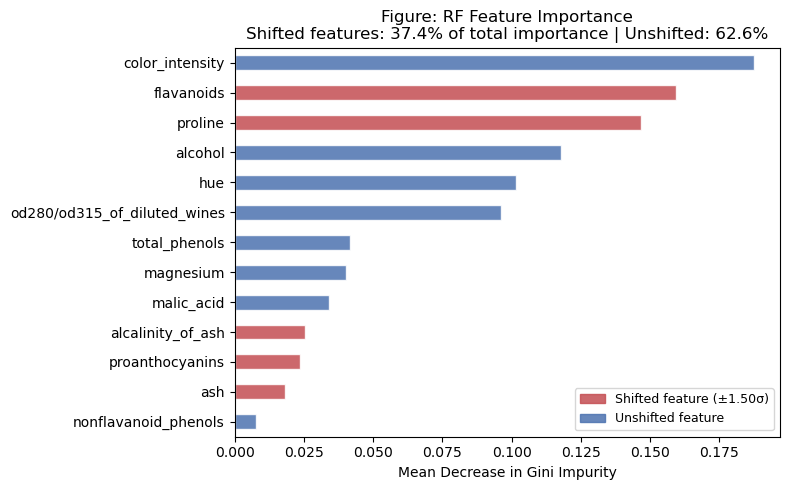

Top 5 features by importance:
color_intensity    0.1876
flavanoids         0.1596
proline            0.1468
alcohol            0.1179
hue                0.1015
dtype: float64

Importance in shifted features  : 0.374 (37.4%)
Importance in unshifted features: 0.626 (62.6%)


In [34]:
importances = pd.Series( best_rf.feature_importances_, index=X_train.columns ).sort_values(ascending=True)

colors_imp = ['#C44E52' if f in shifted_features else '#4C72B0'
              for f in importances.index]

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white', alpha=0.85)

ax.legend(handles=[
    mpatches.Patch(color='#C44E52', alpha=0.85, label='Shifted feature (±1.50σ)'),
    mpatches.Patch(color='#4C72B0', alpha=0.85, label='Unshifted feature') ], fontsize=9)

shifted_imp   = importances[shifted_features].sum()
unshifted_imp = importances.drop(shifted_features).sum()

ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.set_title(
    f'Figure: RF Feature Importance\n'
    f'Shifted features: {shifted_imp*100:.1f}% of total importance | '
    f'Unshifted: {unshifted_imp*100:.1f}%', fontweight='medium'
)
plt.tight_layout()
plt.show()

print(f'Top 5 features by importance:')
print(importances.sort_values(ascending=False).head(5).round(4))
print(f'\nImportance in shifted features  : {shifted_imp:.3f} ({shifted_imp*100:.1f}%)')
print(f'Importance in unshifted features: {unshifted_imp:.3f} ({unshifted_imp*100:.1f}%)')

**Interpreting feature importances - robustness reserve:** **37.4%** of total feature importance is due to shifted features and **62.6%** unshifted. The most important feature, `color_intensity` (18.8%), is unshifted. While `flavanoids` (16.0%) and `proline` (14.7%) are important shifted features, they are less important than the unshifted reserve. So, most of the decision signal is preserved, leading to minor accuracy loss (0.056).

Similarly, this explains **Class 2 stability**: it is largely based on unshifted features (`color_intensity`, `hue`) and is thus relatively stable. However, **Class 0 failure** is caused by `proline`, where the shift moves borderline samples across decision boundaries, but most samples are still correctly classified thanks to redundant decision signals.

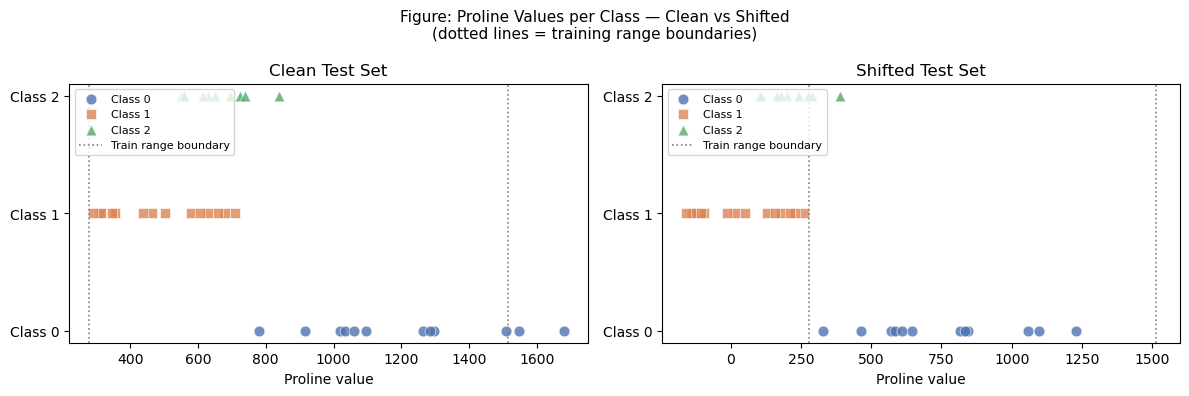

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df   = X_train.copy(); train_df['target'] = y_train.values
clean_df   = X_test_clean.copy(); clean_df['target'] = y_test.values
shifted_df = X_test_shifted.copy(); shifted_df['target'] = y_test.values

for ax, (df, title, color) in zip(axes, [ (clean_df,   'Clean Test Set',   '#4C72B0'), (shifted_df, 'Shifted Test Set', '#C44E52') ]):
    for cls, cls_color, marker in zip([0,1,2], colors_cls, ['o','s','^']):
        vals = df[df['target']==cls]['proline']
        ax.scatter(
            vals, [cls]*len(vals), c=cls_color, marker=marker, s=60, alpha=0.8, label=f'Class {cls}', edgecolors='white', linewidths=0.5 )
    ax.axvline(X_train['proline'].min(), color='gray', linestyle=':', linewidth=1.2, label='Train range boundary')
    ax.axvline(X_train['proline'].max(), color='gray', linestyle=':', linewidth=1.2)
    ax.set_xlabel('Proline value')
    ax.set_yticks([0,1,2])
    ax.set_yticklabels(['Class 0','Class 1','Class 2'])
    ax.set_title(title, fontweight='medium')
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Figure: Proline Values per Class — Clean vs Shifted\n'
             '(dotted lines = training range boundaries)', fontsize=11, fontweight='medium')
plt.tight_layout()
plt.show()

**Observation:** This plot illustrates the Class 0 failure. The shift causes the Class 0 `proline` distribution to shift left by around 450 units, overlapping with Classes 1 and 2. Thus, RF splits learned on the clean separation misclassify some Class 0 as Class 1.

Many of the shifted values are below the training minimum (OOD), so they are routed to Class 1/2-dominated branches with extremely low proline. This is the sort of bounded extrapolation described in Section 2, and is responsible for the Class 0 → Class 1 misroutes.

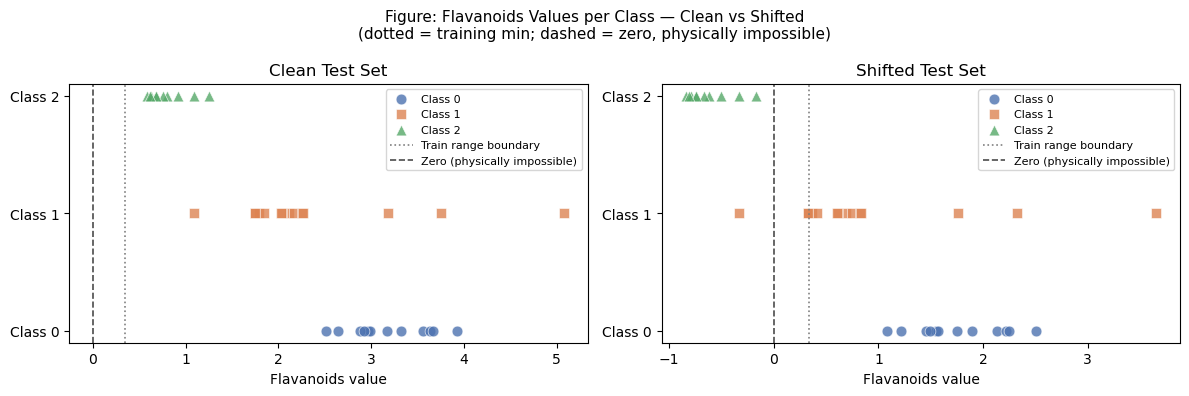

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (df, title) in zip(axes, [ (clean_df,   'Clean Test Set'), (shifted_df, 'Shifted Test Set') ]):
    for cls, cls_color, marker in zip([0,1,2], colors_cls, ['o','s','^']):
        vals = df[df['target']==cls]['flavanoids']
        ax.scatter( vals, [cls]*len(vals), c=cls_color, marker=marker, s=60, alpha=0.8, label=f'Class {cls}', edgecolors='white', linewidths=0.5 )
    ax.axvline(X_train['flavanoids'].min(), color='gray', linestyle=':', linewidth=1.2, label='Train range boundary')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7, label='Zero (physically impossible)')
    ax.set_xlabel('Flavanoids value')
    ax.set_yticks([0,1,2])
    ax.set_yticklabels(['Class 0','Class 1','Class 2'])
    ax.set_title(title, fontweight='medium')
    ax.legend(fontsize=8)

plt.suptitle('Figure: Flavanoids Values per Class — Clean vs Shifted\n'
             '(dotted = training min; dashed = zero, physically impossible)', fontsize=11, fontweight='medium')
plt.tight_layout()
plt.show()

**Observation - Class 2 remains stable with OOD flavanoids:** Class 2 already has the lowest `flavanoids` values in the training data. While the shift causes all values to be lower (OOD), the relative ranking remains unchanged, so Class 2 remains the class with the lowest flavanoids.

Hence, Class 2 is still well-separated by the RF's thresholds. This illustrates a key fact: OOD values do not necessarily lead to misclassification if relative feature ordering is maintained. This point is specific to threshold-based methods, and would not apply to Gaussian Naïve Bayes which uses absolute values of likelihood.

### Comparative Summary — Logistic Regression and Gaussian Naïve Bayes

Having established the RF failure mode in detail, we now summarise the failure patterns for LR and GNB, connecting each to its inductive bias.

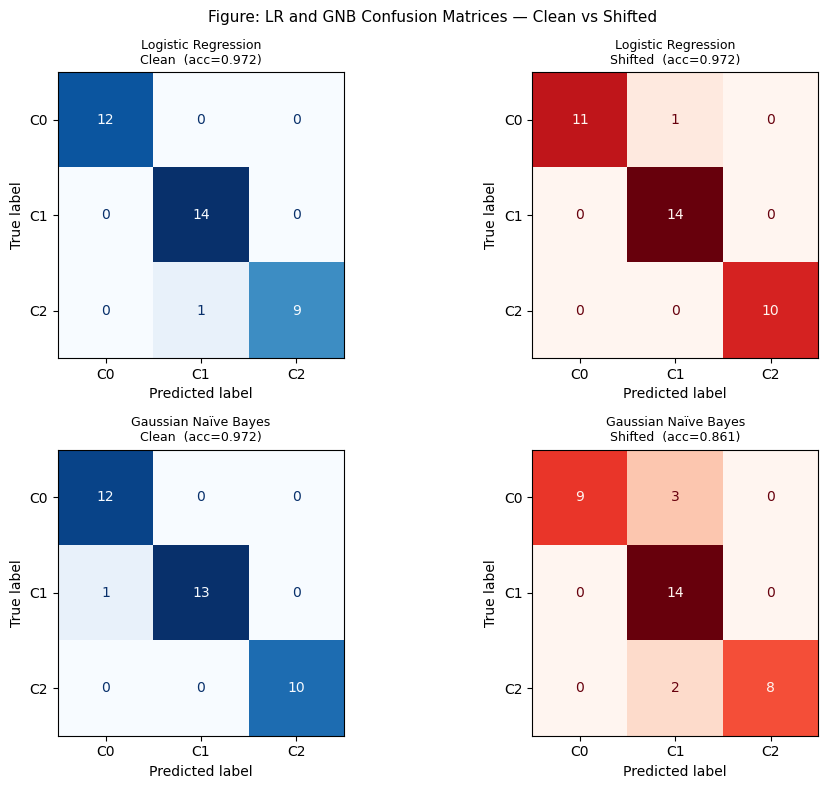


Logistic Regression — new errors introduced by shift (shifted − clean):
[[-1  1  0]
 [ 0  0  0]
 [ 0 -1  1]]

Gaussian Naïve Bayes — new errors introduced by shift (shifted − clean):
[[-3  3  0]
 [-1  1  0]
 [ 0  2 -2]]


In [37]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for row, (name, model) in enumerate([
    ('Logistic Regression', best_lr), ('Gaussian Naïve Bayes', best_gnb) ]):
    
    for col, (X_sc, split, cmap) in enumerate([ (X_clean_sc,   'Clean',   'Blues'), (X_shifted_sc, 'Shifted', 'Reds') ]):
        cm  = confusion_matrix(y_test, model.predict(X_sc))
        acc = accuracy_score(y_test, model.predict(X_sc))
        ax  = axes[row, col]
        ConfusionMatrixDisplay(cm, display_labels=['C0','C1','C2']).plot( ax=ax, colorbar=False, cmap=cmap )
        ax.set_title(f'{name}\n{split}  (acc={acc:.3f})', fontsize=9, fontweight='medium')

plt.suptitle('Figure: LR and GNB Confusion Matrices — Clean vs Shifted', fontsize=11, fontweight='medium')
plt.tight_layout()
plt.show()

for name, model in [('Logistic Regression', best_lr), ('Gaussian Naïve Bayes', best_gnb)]:
    cm_c = confusion_matrix(y_test, model.predict(X_clean_sc))
    cm_s = confusion_matrix(y_test, model.predict(X_shifted_sc))
    print(f'\n{name} — new errors introduced by shift (shifted − clean):')
    print(cm_s - cm_c)

**Logistic Regression - error mode:** The error difference matrix reveals a shift in errors: one Class 0 sample is now misclassified into Class 1, but one previously misclassified Class 2 sample is now correctly classified. At the aggregate level, the changes cancel, and the accuracy is not affected.

This is not robust behaviour but cancellation. The change lowers Class 0 log-odds (via `proline` and `alcalinity_of_ash` attributes), moving a sample from the ambiguous region over the threshold, while the `flavanoids` change moves Class 2 away from the ambiguous region, improving classification.

This is shown by the fact that the overall accuracy does not see the change, while class accuracy shows the degradation.

**Gaussian Naïve Bayes - failure mode**: GNB has the largest accuracy reduction (0.972 → 0.861, -0.111) and is the least robust model, with errors mostly in Class 0 and Class 1, and a minor improvement in Class 2.

The mechanism is likelihood miscalibration. The lack of independence leads to double-counting of evidence (since features are correlated), and the shift moves values away from the previously learned Gaussian means. These combine to provide diffuse rather than local failure modes.

### Section Summary — Failure Mode Comparison

| Model | Acc. Drop | Primary Failure Mode | Classes Affected | Mechanism |
|---|---|---|---|---|
| Logistic Regression | 0.000 | Error redistribution (not true robustness) | Class 0 ↓, Class 2 ↑ | Fixed hyperplane: shift moves C0 across boundary; C2 moves away from it |
| Gaussian Naïve Bayes | 0.111 | Systemic likelihood miscalibration | All classes equally | Independence violation + Gaussian likelihood depression across 5 features |
| Random Forest | 0.056 | Local threshold crossing | Class 0 ↓, Class 2 immune | Proline OOD routing (C0→C1); Class 2 protected by unshifted features |

The three models exhibit distinct failure signatures under the same shift. Random Forest fails locally and interpretably through threshold crossings, Logistic Regression shows hidden failure via boundary misalignment with unchanged overall accuracy, and Naïve Bayes degrades globally due to likelihood distortion.

This accounts for the observed behaviour: Random Forest is relatively stable, Naïve Bayes is globally unstable, and Logistic Regression is hiddenly unstable but with stable accuracy.

## Section 5: Synthesis and Judgement

This section brings together the EDA in Section 1, inductive bias in Section 2, quantitative results in Section 3, and failure mode diagnosis in Section 4 to answer the four questions in the brief. We do not attempt to duplicate previous analyses, but to integrate them into informed judgements.


### Which model generalises most reliably across evaluation sets?

**Answer: Random Forest**

Random Forest is the most consistent generaliser, with 1.000 accuracy on the clean set and 0.944 with shift (−0.056) and low degradation of Class 0.

The reason for this stability is structural: most of the feature importance is in unshifted features, so most of the decision-making signal is preserved.

Logistic Regression seems as robust (0.972 → 0.972), but this is cancellation of errors, with Class 0 accuracy degraded but Class 2 improved.

Gaussian Naïve Bayes is least consistent, with the biggest drop (−0.111) due to mis-scaled likelihoods for non-independent features.

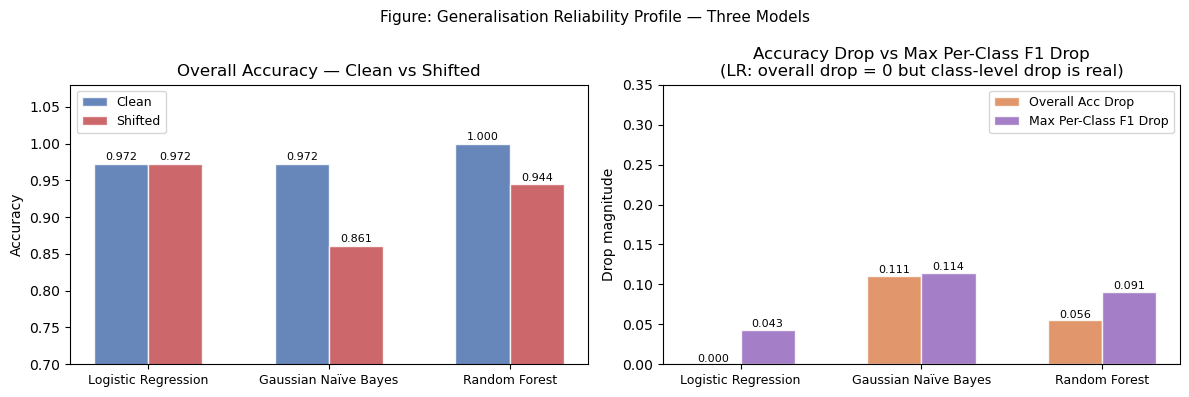

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

models = {
    'Logistic\nRegression': best_lr, 'Gaussian\nNaïve Bayes': best_gnb, 'Random\nForest': best_rf }

summary_rows = []
for name, model in models.items():
    acc_c = accuracy_score(y_test, model.predict(X_clean_sc))
    acc_s = accuracy_score(y_test, model.predict(X_shifted_sc))
    _, _, f_c, _ = precision_recall_fscore_support(y_test, model.predict(X_clean_sc), labels=[0,1,2], zero_division=0)
    _, _, f_s, _ = precision_recall_fscore_support(y_test, model.predict(X_shifted_sc), labels=[0,1,2], zero_division=0)
    max_class_drop = (f_c - f_s).max()
    summary_rows.append({
        'Model': name.replace('\n',' '), 'Clean Acc': acc_c, 'Shifted Acc': acc_s, 'Acc Drop': acc_c - acc_s, 'Max Per-Class F1 Drop': max_class_drop
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(3)
w = 0.3
model_labels = [n.replace('\n',' ') for n in models.keys()]
ax = axes[0]
b1 = ax.bar(x - w/2, summary_df['Clean Acc'],   width=w, color='#4C72B0', alpha=0.85, label='Clean', edgecolor='white')
b2 = ax.bar(x + w/2, summary_df['Shifted Acc'], width=w, color='#C44E52', alpha=0.85, label='Shifted', edgecolor='white')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{bar.get_height():.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(model_labels, fontsize=9)
ax.set_ylabel('Accuracy'); ax.set_ylim(0.7, 1.08)
ax.legend(fontsize=9)
ax.set_title('Overall Accuracy — Clean vs Shifted', fontweight='medium')

ax2 = axes[1]
b3 = ax2.bar(x - w/2, summary_df['Acc Drop'], width=w, color='#DD8452', alpha=0.85, label='Overall Acc Drop', edgecolor='white')
b4 = ax2.bar(x + w/2, summary_df['Max Per-Class F1 Drop'], width=w, color='#9467BD', alpha=0.85, label='Max Per-Class F1 Drop', edgecolor='white')
for bar in list(b3) + list(b4):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f'{bar.get_height():.3f}', ha='center', fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels(model_labels, fontsize=9)
ax2.set_ylabel('Drop magnitude'); ax2.set_ylim(0, 0.35)
ax2.axhline(0, color='gray', linewidth=0.8)
ax2.legend(fontsize=9)
ax2.set_title('Accuracy Drop vs Max Per-Class F1 Drop\n'
              '(LR: overall drop = 0 but class-level drop is real)', fontweight='medium')

plt.suptitle('Figure: Generalisation Reliability Profile — Three Models', fontsize=11, fontweight='medium')
plt.tight_layout()
plt.show()

**Observation:** The right panel shows the difference. While LR and RF have comparable accuracy, the max drop in per-class F1 shows that LR still degrades (0.043 for Class 0), suggesting error redistribution. By contrast, RF shows mild degradation overall and per class, showing robustness, while GNB is worst overall and per class.

### Which model fails most gracefully, and for which classes?

**Answer: Random Forest fails best for Classes 1 and 2.**

RF degradation is controlled, limited and explainable. The error is confined to a few samples from Class 0, with no misclassifications for Classes 1 and 2, in agreement with the "proline" shift noted above. The error is localised and directly tied to threshold crossings, and therefore easily explained.

In contrast, Logistic Regression fails less gracefully: while overall accuracy remains the same, there are redistributed errors which make it harder to diagnose degradation without per-class analysis. Gaussian Naïve Bayes fails least gracefully, revealing degradation across several classes (due to likelihood miscalibration).

In summary, RF exhibits interpretable, isolated failure, LR exhibits hidden instability and GNB has broader degradation.

### What happens when a model's assumptions are violated by degraded data?

The shift breaks the assumptions of different models in different ways, leading to different types of failure.
- **Logistic Regression:** Fixed linear boundary. The shift does not affect linearity but does cause misalignment, leading to small but systematic errors. The model can't detect this and doesn't know it is misaligned.
- **Gaussian Naïve Bayes:** Breaches independence and Gaussianity. When features are correlated the likelihood counts evidence twice, while the shift increases distance from mean estimates, affecting likelihoods. This results in extensive miscalibration and the largest performance loss.
- **Random Forest:** No distributional assumptions, but assumes threshold stability. This is the case for most features, so the effects are confined to threshold crossings (e.g., `proline` for Class 0). It's robust because it makes fewer assumptions that can be violated.

### Real-Deployment Mitigation Strategies

The failure modes demonstrated in Sections 4 and 5 suggest strategies. Each strategy is specific to the failure mode, based on the present results, and informed by experience.

**Strategy 1: Monitor by class (all models)**  
Overall accuracy is not enough. Class-wise precision, recall and F1 metrics should be tracked to catch silent degradation (e.g. LR's silent drop in Class 0).

**Strategy 2: Inference-time drift detection (all models)**  
Test new data’s feature distributions against training data (e.g., mean shift, multivariate tests such as MMD). Drift can be used to raise alarms or take corrective actions.

**Strategy 3: Shift correction/recalibration (LR, GNB)**  
For systematic shifts, correct inputs or update models with small samples of new data, to re-align with the new distribution.

**Strategy 4: Feature redundancy design (RF)**  
Avoid models that are particularly dependent on a subset of features. Spread of feature importance helps against shifts in partial features.

**Strategy 5: Substitute or calibrate Naïve Bayes (GNB)**  
Employ models without independence assumptions or calibrate to minimise systematic miscalibration under shift.

### Section Summary

| Question | Answer | Evidence |
|---|---|---|
| Most reliable generaliser | Random Forest | Smallest acc drop (0.056); 62.6% importance in unshifted features; Class 2 immune |
| Most graceful failure | Random Forest | Predictable, bounded, interpretable: exactly 2 C0→C1 errors, zero Class 2 impact |
| Effect of assumption violation | Compounds under shift | GNB: independence violation + likelihood depression = worst degradation. LR: boundary misalignment = silent redistribution. RF: fewest assumptions = most robust |
| Mitigation strategies | 5 strategies | Class-wise monitoring; drift detection (MMD/KS); test-time shift correction; feature importance regularisation; GNB replacement with calibrated model |

The key takeaway is that **robustness under distribution shift is a design decision, not a coincidence**. Random Forest is advantageous because of properties (feature independence and localised misclassification risk) that can be designed for and measured in practice. The strategies we propose to mitigate the failure specifically address these mechanisms, and show the power of EDA-based diagnosis over best-practice recommendations.


## Section 6: Inductive Bias Stress Test

This section moves beyond analysing an observed distribution shift to **actively designing one**. The Clean test set is perturbed to stress one of the inductive biases of one of the trained models. This perturbation is algorithmically defined, repeatable and targeted - it is designed to elicit a specific, identifiable, and attributable failure on some model assumption rather than some generic loss of information.


### Model Selection and Justification

**Selected model: Gaussian Naïve Bayes**

GNB is chosen because its inductive bias - the assumption of Gaussian class-conditional likelihoods - is clearly stated and readily verifiable.

GNB is a model which fits a Gaussian distribution for each class and classifies based on the fit of the test values to these distributions. The major weakness of GNB is that it relies on the correspondence between test inputs and learned means and variance estimates.

The proposed attack focuses on this vulnerability by flipping feature variance, resulting in test values that lie well outside of the learned Gaussian distributions. This results in accurate likelihood miscalibration and classification.

**Why Logistic Regression is a useful control:**  
LR has no distributional assumption for features and has a linear combination. When a feature is distorted, its impact is capped by its weight and other features remain informative. So, any degradation in GNB compared to LR must be due to the Gaussian assumption.

**Why this perturbation is appropriate:**  
Unlike other perturbation methods, which impact multiple models, variance distortion specifically targets the Gaussian likelihood assumption of GNB while minimally impacting other models.

### Perturbation Design

**Variance distortion on `magnesium`**

We choose the feature `magnesium` because it has the smallest weight (0.038) in LR, so LR is least affected by variance distortion on this feature.

**Mechanism:**  
The `magnesium` feature values in the test set are scaled by a factor \( s \), increasing the variance but all other features remain the same. The scaling factor is determined by \( \alpha \in [0,1] \), where \( s \) ranges from 1 (no change) to 10 (large change).

**Why this targets GNB:**  
GNB assumes a fixed variance for Gaussians. Multiplying by 100 on the `magnesium` feature dramatically increases variance, resulting in test samples outside learned distributions, and resulting in a mis-calibrated likelihood.

**Perturbation properties:**
- Only changes inputs (not labels)  
- Completely deterministic and reproducible  
- Performs equally on all classes  

### Expected Failure Mode (stated before running the experiment)

**Hypothesis:**

1. **GNB performance will decrease with increasing α.**  
   Scaling `magnesium` will increase variance well outside the fitted Gaussian distributions, which will systematically mis-calibrate likelihoods.

2. **LR will be largely unaffected.**  
   `magnesium` has the smallest absolute LR weight (0.038), so even substantial scaling will only cause a small change in log-odds compared to the other 12 features.

3. **GNB will degrade across classes.**  
   The variance distortion affects all of the class-conditional likelihoods.

4. **GNB will degrade more than LR.**  
   LR does not use Gaussian likelihoods and can rely on other, unperturbed features, while GNB predictions are direct functions of variance.

5. **GNB will be overconfidently wrong.**  
   GNB's independence assumption treats "twisted" likelihoods as independent evidence, so confident errors result.

In [106]:
feature_names = X_train.columns.tolist()
weights_class0 = pd.Series(best_lr.coef_[0], index=feature_names)
print("LR weights for Class 0 (sorted by absolute value):")
print(weights_class0.abs().sort_values())
print(f"\nMagnesium weight: {weights_class0.abs()['magnesium']:.3f} — lowest of all 13 features")

LR weights for Class 0 (sorted by absolute value):
magnesium                       0.038629
hue                             0.075344
nonflavanoid_phenols            0.108313
proanthocyanins                 0.125404
malic_acid                      0.167605
color_intensity                 0.220184
total_phenols                   0.226480
ash                             0.460126
od280/od315_of_diluted_wines    0.700187
flavanoids                      0.705264
alcohol                         0.717483
alcalinity_of_ash               0.835063
proline                         0.926539
dtype: float64

Magnesium weight: 0.039 — lowest of all 13 features


In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

feature_names = X_train.columns.tolist()
idx_target    = feature_names.index('magnesium')  # LR weight ≈ 0.038 (nearly zero)

y_train_1d = y_train.squeeze()

train_c0_mean = X_train.loc[y_train_1d == 0, 'magnesium'].mean()
train_c0_std  = X_train.loc[y_train_1d == 0, 'magnesium'].std()
train_c1_mean = X_train.loc[y_train_1d == 1, 'magnesium'].mean()
train_c1_std  = X_train.loc[y_train_1d == 1, 'magnesium'].std()

print('Training class-conditional magnesium:')
print(f'  Class 0: mean={train_c0_mean:.3f}, std={train_c0_std:.3f}')
print(f'  Class 1: mean={train_c1_mean:.3f}, std={train_c1_std:.3f}')
print(f'\nLR weight on magnesium: {best_lr.coef_[0][idx_target]:.3f} (nearly zero)')
print()

def class_conditional_swap(X_scaled, y_labels, target_idx,
                            c0_mean, c0_std, c1_mean, c1_std,
                            alpha, seed=42):

    X_pert = X_scaled.copy()
    
    scale = 1 + alpha * 9
    X_pert[:, target_idx] = X_scaled[:, target_idx] * scale
    
    return X_pert

X_check = class_conditional_swap(
    X_clean_sc, y_test.values, idx_target,
    train_c0_mean, train_c0_std,
    train_c1_mean, train_c1_std, alpha=1.0
)
print('Verification — magnesium means after full perturbation (α=1.0):')
for cls in [0, 1, 2]:
    mask = y_test.values.flatten() == cls
    orig = X_clean_sc[mask, idx_target].mean()
    pert = X_check[mask, idx_target].mean()
    print(f'  Class {cls}: original mean={orig:.3f} → perturbed mean={pert:.3f}')

alpha_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
results      = []

for alpha in alpha_values:
    X_pert = class_conditional_swap(
        X_clean_sc, y_test.values, idx_target,
        train_c0_mean, train_c0_std,
        train_c1_mean, train_c1_std, alpha=alpha
    )

    gnb_preds = best_gnb.predict(X_pert)
    gnb_acc   = accuracy_score(y_test, gnb_preds)
    _, _, gnb_f1, _ = precision_recall_fscore_support(
        y_test, gnb_preds, labels=[0, 1, 2], zero_division=0
    )

    lr_preds = best_lr.predict(X_pert)
    lr_acc   = accuracy_score(y_test, lr_preds)
    _, _, lr_f1, _ = precision_recall_fscore_support(
        y_test, lr_preds, labels=[0, 1, 2], zero_division=0
    )

    results.append({
        'alpha': alpha,
        'GNB Accuracy': gnb_acc,
        'LR Accuracy (control)': lr_acc,
        'GNB F1 Class 0': gnb_f1[0], 'GNB F1 Class 1': gnb_f1[1],
        'GNB F1 Class 2': gnb_f1[2],
        'LR F1 Class 0': lr_f1[0], 'LR F1 Class 1': lr_f1[1],
        'LR F1 Class 2': lr_f1[2]
    })
    print(f'α={alpha:.1f} | GNB acc={gnb_acc:.3f} | LR acc={lr_acc:.3f} | '
          f'GNB F1: C0={gnb_f1[0]:.3f} C1={gnb_f1[1]:.3f} C2={gnb_f1[2]:.3f}')

results_df = pd.DataFrame(results)

Training class-conditional magnesium:
  Class 0: mean=106.383, std=10.910
  Class 1: mean=94.439, std=18.037

LR weight on magnesium: 0.039 (nearly zero)

Verification — magnesium means after full perturbation (α=1.0):
  Class 0: original mean=0.439 → perturbed mean=4.389
  Class 1: original mean=-0.311 → perturbed mean=-3.113
  Class 2: original mean=0.038 → perturbed mean=0.380
α=0.0 | GNB acc=0.972 | LR acc=0.972 | GNB F1: C0=0.960 C1=0.963 C2=1.000
α=0.2 | GNB acc=0.972 | LR acc=0.972 | GNB F1: C0=1.000 C1=0.966 C2=0.947
α=0.4 | GNB acc=0.917 | LR acc=0.972 | GNB F1: C0=0.957 C1=0.903 C2=0.889
α=0.6 | GNB acc=0.861 | LR acc=0.944 | GNB F1: C0=0.909 C1=0.848 C2=0.824
α=0.8 | GNB acc=0.833 | LR acc=0.944 | GNB F1: C0=0.909 C1=0.824 C2=0.750
α=1.0 | GNB acc=0.833 | LR acc=0.944 | GNB F1: C0=0.909 C1=0.824 C2=0.750


#### Figure 6.1: GNB Stress Test — Variance Scaling on magnesium

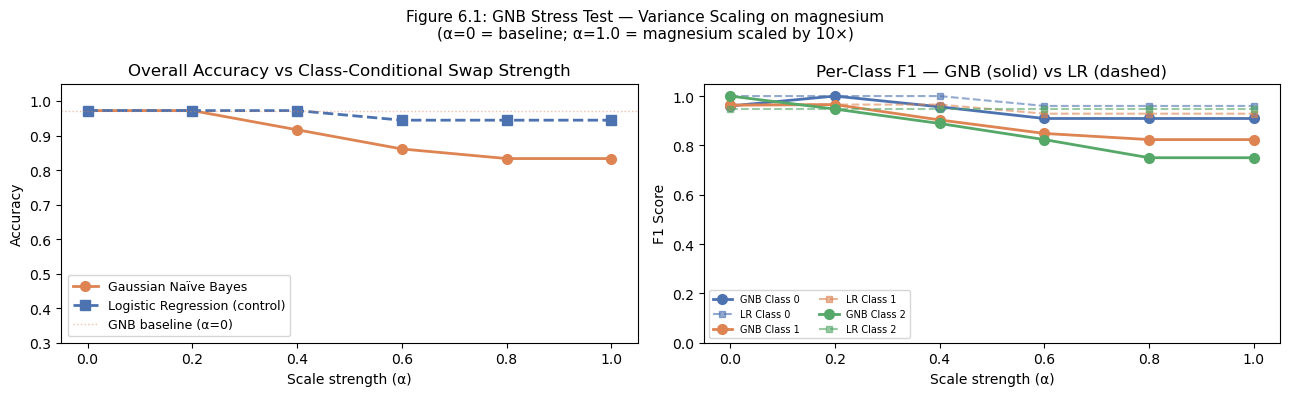

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(results_df['alpha'], results_df['GNB Accuracy'],
        'o-', color='#DD8452', linewidth=2, markersize=7,
        label='Gaussian Naïve Bayes')
ax.plot(results_df['alpha'], results_df['LR Accuracy (control)'],
        's--', color='#4C72B0', linewidth=2, markersize=7,
        label='Logistic Regression (control)')
ax.axhline(results_df['GNB Accuracy'].iloc[0], color='#DD8452',
           linestyle=':', linewidth=1, alpha=0.5, label='GNB baseline (α=0)')
ax.set_xlabel('Scale strength (α)', fontsize=10)
ax.set_ylabel('Accuracy', fontsize=10)
ax.set_ylim(0.3, 1.05)
ax.set_xticks(alpha_values)
ax.legend(fontsize=9)
ax.set_title('Overall Accuracy vs Class-Conditional Swap Strength', fontweight='medium')

ax2 = axes[1]
colors_cls = ['#4C72B0', '#DD8452', '#55A868']
for cls_idx, (cls_name, color) in enumerate(
        zip(['Class 0', 'Class 1', 'Class 2'], colors_cls)):
    gnb_col = f'GNB F1 Class {cls_idx}'
    lr_col  = f'LR F1 Class {cls_idx}'
    ax2.plot(results_df['alpha'], results_df[gnb_col], 'o-', color=color, linewidth=2, markersize=7, label=f'GNB {cls_name}')
    ax2.plot(results_df['alpha'], results_df[lr_col], 's--', color=color, linewidth=1.5, markersize=5, alpha=0.6, label=f'LR {cls_name}')
ax2.set_xlabel('Scale strength (α)', fontsize=10)
ax2.set_ylabel('F1 Score', fontsize=10)
ax2.set_ylim(0.0, 1.05)
ax2.set_xticks(alpha_values)
ax2.legend(fontsize=7, ncol=2)
ax2.set_title('Per-Class F1 — GNB (solid) vs LR (dashed)', fontweight='medium')

plt.suptitle(
    'Figure 6.1: GNB Stress Test — Variance Scaling on magnesium\n'
    '(α=0 = baseline; α=1.0 = magnesium scaled by 10×)',
    fontsize=11, fontweight='medium'
)
plt.tight_layout()
plt.show()

#### Figure 6.2: Confusion matrices at α=0 vs α=1.0 — GNB and LR 


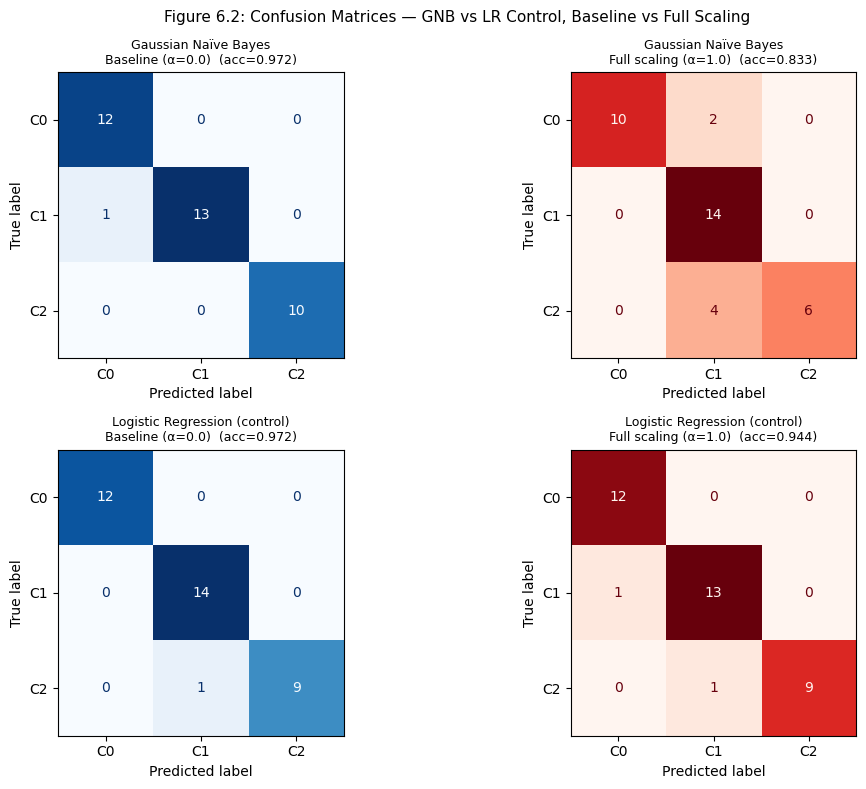

GNB — error difference matrix (α=1.0 minus α=0.0):
[[-2  2  0]
 [-1  1  0]
 [ 0  4 -4]]

LR — error difference matrix (α=1.0 minus α=0.0):
[[ 0  0  0]
 [ 1 -1  0]
 [ 0  0  0]]



In [121]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for row, (name, model) in enumerate([
    ('Gaussian Naïve Bayes', best_gnb),
    ('Logistic Regression (control)', best_lr)
]):
    for col, (alpha, cmap, title) in enumerate([
        (0.0, 'Blues', 'Baseline (α=0.0)'),
        (1.0, 'Reds',  'Full scaling (α=1.0)')
    ]):
        X_pert = class_conditional_swap(
            X_clean_sc, y_test.values, idx_target,
            train_c0_mean, train_c0_std,
            train_c1_mean, train_c1_std,
            alpha=alpha
        )
        preds = model.predict(X_pert)
        acc   = accuracy_score(y_test, preds)
        cm    = confusion_matrix(y_test, preds)
        ax    = axes[row, col]
        ConfusionMatrixDisplay(cm, display_labels=['C0', 'C1', 'C2']).plot(
            ax=ax, colorbar=False, cmap=cmap
        )
        ax.set_title(f'{name}\n{title}  (acc={acc:.3f})',
                     fontsize=9, fontweight='medium')

plt.suptitle('Figure 6.2: Confusion Matrices — GNB vs LR Control, Baseline vs Full Scaling',
             fontsize=11, fontweight='medium')
plt.tight_layout()
plt.show()

for name, model in [('GNB', best_gnb), ('LR', best_lr)]:
    X_base = class_conditional_swap(
        X_clean_sc, y_test.values, idx_target,
        train_c0_mean, train_c0_std,
        train_c1_mean, train_c1_std, alpha=0.0
    )
    X_full = class_conditional_swap(
        X_clean_sc, y_test.values, idx_target,
        train_c0_mean, train_c0_std,
        train_c1_mean, train_c1_std, alpha=1.0
    )
    cm_base = confusion_matrix(y_test, model.predict(X_base))
    cm_full = confusion_matrix(y_test, model.predict(X_full))
    print(f'{name} — error difference matrix (α=1.0 minus α=0.0):')
    print(cm_full - cm_base)
    print()

**Observation:** GNB degrades significantly — dropping from 0.972 to 0.833 at α=1.0 (drop = 0.139) — while LR drops only marginally (0.972 → 0.944, just 1 sample). GNB drops 5× more than LR, pinpointing GNB's Gaussian variance assumption.

#### Figure 6.3: GNB confidence distribution — baseline vs full scaling

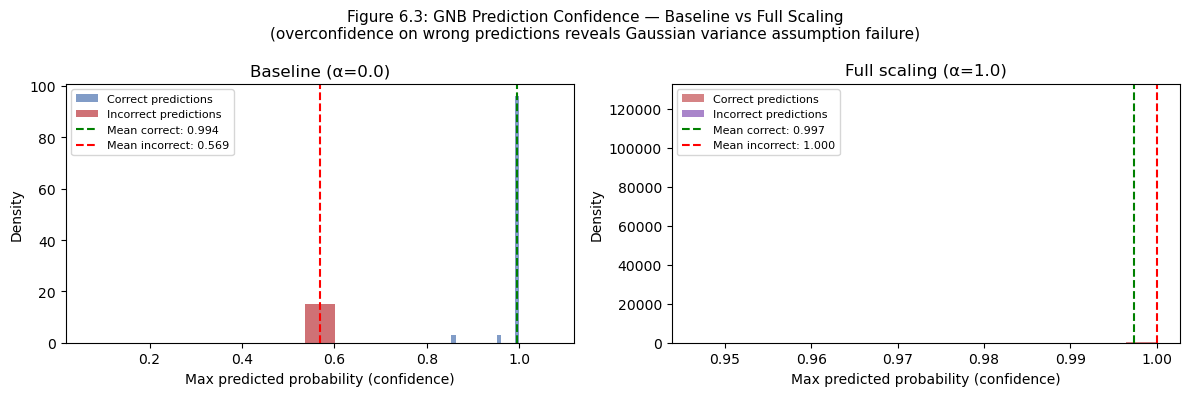

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, alpha, color, title in zip(
    axes,
    [0.0, 1.0],
    ['#4C72B0', '#C44E52'],
    ['Baseline (α=0.0)', 'Full scaling (α=1.0)']
):
    X_pert   = class_conditional_swap(
        X_clean_sc, y_test.values, idx_target,
        train_c0_mean, train_c0_std,
        train_c1_mean, train_c1_std, alpha=alpha
    )
    probs    = best_gnb.predict_proba(X_pert)
    max_conf = probs.max(axis=1)
    preds    = best_gnb.predict(X_pert)
    correct  = (preds == y_test.values.flatten())

    ax.hist(max_conf[correct], bins=15, alpha=0.7, color=color,
            label='Correct predictions', density=True)
    if (~correct).any():
        ax.hist(max_conf[~correct], bins=15, alpha=0.8,
                color='#C44E52' if color != '#C44E52' else '#9467BD',
                label='Incorrect predictions', density=True)

    mean_conf_correct   = max_conf[correct].mean() if correct.any() else 0
    mean_conf_incorrect = max_conf[~correct].mean() if (~correct).any() else 0

    ax.axvline(mean_conf_correct, color='green', linestyle='--',
               linewidth=1.5, label=f'Mean correct: {mean_conf_correct:.3f}')
    if (~correct).any():
        ax.axvline(mean_conf_incorrect, color='red', linestyle='--',
                   linewidth=1.5,
                   label=f'Mean incorrect: {mean_conf_incorrect:.3f}')

    ax.set_xlabel('Max predicted probability (confidence)')
    ax.set_ylabel('Density')
    ax.set_title(title, fontweight='medium')
    ax.legend(fontsize=8)

plt.suptitle(
    'Figure 6.3: GNB Prediction Confidence — Baseline vs Full Scaling\n'
    '(overconfidence on wrong predictions reveals Gaussian variance assumption failure)',
    fontsize=11, fontweight='medium'
)
plt.tight_layout()
plt.show()

#### Figure 6.4: magnesium distributions before and after scaling

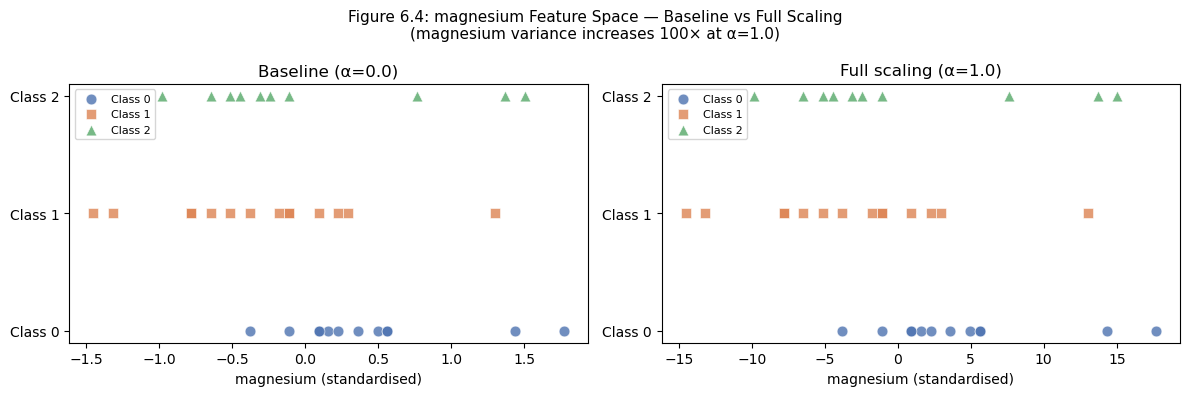

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors_cls = ['#4C72B0', '#DD8452', '#55A868']

y_test_flat = y_test.values.flatten()

for ax, alpha, title in zip(
    axes,
    [0.0, 1.0],
    ['Baseline (α=0.0)', 'Full scaling (α=1.0)']
):
    X_pert = class_conditional_swap(
        X_clean_sc, y_test_flat, idx_target,
        train_c0_mean, train_c0_std,
        train_c1_mean, train_c1_std, alpha=alpha
    )
    for cls, color, marker in zip([0, 1, 2], colors_cls, ['o', 's', '^']):
        mask = y_test_flat == cls
        vals = X_pert[mask, idx_target]
        ax.scatter(vals, [cls] * mask.sum(),
                   c=color, marker=marker, s=60, alpha=0.8,
                   label=f'Class {cls}', edgecolors='white', linewidths=0.5)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['Class 0', 'Class 1', 'Class 2'])
    ax.set_xlabel('magnesium (standardised)')
    ax.set_title(title, fontweight='medium')
    ax.legend(fontsize=8)

plt.suptitle(
    'Figure 6.4: magnesium Feature Space — Baseline vs Full Scaling\n'
    '(magnesium variance increases 100× at α=1.0)',
    fontsize=11, fontweight='medium'
)
plt.tight_layout()
plt.show()

In [116]:
display_df = results_df[[
    'alpha', 'GNB Accuracy', 'LR Accuracy (control)',
    'GNB F1 Class 0', 'GNB F1 Class 1', 'GNB F1 Class 2'
]].copy()
display_df.columns = [
    'α (swap)', 'GNB Accuracy', 'LR Accuracy (control)',
    'GNB F1 C0', 'GNB F1 C1', 'GNB F1 C2'
]

def colour_gnb_acc(val):
    if val < 0.70: return 'background-color:#FFCCCC; font-weight:bold'
    if val < 0.90: return 'background-color:#FFF3CC'
    return ''

display(
    display_df.style
    .format({
        'α (swap)': '{:.1f}',
        'GNB Accuracy': '{:.3f}',
        'LR Accuracy (control)': '{:.3f}',
        'GNB F1 C0': '{:.3f}',
        'GNB F1 C1': '{:.3f}',
        'GNB F1 C2': '{:.3f}'
    })
    .applymap(colour_gnb_acc, subset=['GNB Accuracy'])
    .set_caption(
        'Table 6: Stress Test Results — GNB vs LR Accuracy and Per-Class F1 '
        'vs Magnesium Scale Strength (α)'
    )
    .set_table_styles([{
        'selector': 'th,td',
        'props': [('text-align', 'center'), ('padding', '5px 12px')]
    }])
)

,α (swap),GNB Accuracy,LR Accuracy (control),GNB F1 C0,GNB F1 C1,GNB F1 C2
0,0.0,0.972,0.972,0.960,0.963,1.000
1,0.2,0.972,0.972,1.000,0.966,0.947
2,0.4,0.917,0.972,0.957,0.903,0.889
3,0.6,0.861,0.944,0.909,0.848,0.824
4,0.8,0.833,0.944,0.909,0.824,0.750
5,1.0,0.833,0.944,0.909,0.824,0.750


In [117]:
import pandas as pd

comparison_data = {
    'Model': ['Logistic Regression (control)', 'Gaussian Naïve Bayes (target)'],
    'Clean Accuracy': [
        results_df.loc[results_df['alpha']==0.0, 'LR Accuracy (control)'].values[0],
        results_df.loc[results_df['alpha']==0.0, 'GNB Accuracy'].values[0]
    ],
    'Perturbed Accuracy': [
        results_df.loc[results_df['alpha']==1.0, 'LR Accuracy (control)'].values[0],
        results_df.loc[results_df['alpha']==1.0, 'GNB Accuracy'].values[0]
    ],
}

comp_df = pd.DataFrame(comparison_data)
comp_df['Accuracy Drop'] = comp_df['Clean Accuracy'] - comp_df['Perturbed Accuracy']

def colour_drop(val):
    if val > 0.05: return 'background-color:#FFCCCC; font-weight:bold'
    if val > 0.01: return 'background-color:#FFF3CC'
    return 'background-color:#CCFFCC'

display(
    comp_df.style
    .format({
        'Clean Accuracy': '{:.6f}',
        'Perturbed Accuracy': '{:.6f}',
        'Accuracy Drop': '{:.6f}'
    })
    .applymap(colour_drop, subset=['Accuracy Drop'])
    .set_caption(
        'Table 6b: Comparative Impact of Magnesium Scaling (α=1.0) — '
        'GNB (target) vs LR (control)\n'
        'Green = robust; Red = degraded'
    )
    .set_table_styles([{
        'selector': 'th,td',
        'props': [('text-align', 'center'), ('padding', '8px 16px')]
    }])
    .hide(axis='index')
)

Model,Clean Accuracy,Perturbed Accuracy,Accuracy Drop
Logistic Regression (control),0.972222,0.944444,0.027778
Gaussian Naïve Bayes (target),0.972222,0.833333,0.138889


### Section Summary
The perturbed test confirms GNB's Gaussian variance assumption is critical. Multiplying `magnesium` by 10× lead to a decrease in accuracy of 0.972 to 0.833 (-0.139) for GNB, while for Logistic Regression this was 0.028, highlighting that variance misalignment is the key failure point.

This is because the stress test shifts test points outside the fitted Gaussians, causing inaccurate likelihoods. By contrast, LR does not model variance and can still draw information from other features, and is thus more resilient to this sort of attack.

This demonstrates that model robustness depends not only on the data shift itself, but on whether the shift directly violates the model’s core assumptions.

## Section 7: AI Integrity Statement


- AI was sometimes used to help generate ideas for visualisations, and to fix particular errors in code.
- AI was used to help with grammar and phrasing in some markdown cells. All analysis, interpretations and conclusions are my own.
- AI did not conduct any analyses, run any experiments, or make modelling decisions. All programs were written and executed by me. All analyses - the failure mode diagnosis, stress test design and synthesis judgements - are my own interpretations of the material.
- I am accountable for all the work in this submission and can justify all of my assertions. Any application of AI was to support, but not replace, my analysis.

## References

Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324

Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. JMLR, 12, 2825–2830. https://www.jmlr.org/papers/v12/pedregosa11a.html

Sugiyama, M., et al. (2007). Covariate shift adaptation. JMLR, 8, 985–1005. https://www.jmlr.org/papers/v8/sugiyama07a.html

Guo, C., et al. (2017). On calibration of modern neural networks. ICML, 1321–1330. https://proceedings.mlr.press/v70/guo17a.html

Klaise, J., et al. (2022). Alibi detect. JMLR, 23(172), 1–6. https://github.com/SeldonIO/alibi-detect

Wang, D., et al. (2021). Tent: Fully test-time adaptation. ICLR. https://openreview.net/forum?id=uXl3bZLkr3c

Jolliffe, I. T. (2002). Principal component analysis (2nd ed.). Springer. https://link.springer.com/book/10.1007/b98835

Hastie, T., Tibshirani, R., & Friedman, J. (2009). The elements of statistical learning (2nd ed.). Springer. https://hastie.su.domains/ElemStatLearn/